# Notebook 1: Einführung und Daten

**Statistik für Data Science** · Kurs 3,906 · Bachelor Computer Science · HS2026
Universität St. Gallen

---
### Projektteam:
- Andrin Greitmann
- Noah Appenzeller
- Manuel Schmid

---

Dieses Notebook führt die Inhalte von **VL01 (Einführung & Daten)** in Python aus. 

## 0. Setup
Importiert `pandas`, `numpy`, `seaborn` und `matplotlib` und setzt den Seed.

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seed: Startwert für den Zufallsgenerator. Gleicher Seed bei jedem Durchlauf damit Resultate deterministisch & reproduzierbar sind. 
# Den Wert selbst haben wir beliebig gewählt, wir haben ihn als erstes vor der Analyse gewählt und danach nicht mehr geändert.
# Der Seed wird für alles Zufällige in allen Notebooks verwendet.
SEED = 2001
RNG = np.random.default_rng(SEED)

# Plot-Defauls
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7.5, 4.2)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [17]:
import sys

print("Python  ", sys.version.split()[0])
for modul in (np, pd, sns):
    print(f"{modul.__name__:8s}", modul.__version__)
print("Seed    ", SEED)

Python   3.14.4
numpy    2.5.3
pandas   3.0.6
seaborn  0.13.2
Seed     2001


### Unseren Datensatz laden

In [18]:
from ucimlrepo import fetch_ucirepo

# Datensatz direkt aus dem UCI Repository laden (ID 117 = Census-Income KDD)
census_income_kdd = fetch_ucirepo(id=117)

# Etwas spezielles an unserem Datenset: ucimlrepo liefert die Daten aufgeteilt in Features und Target. 
# (Wahrscheinlich für Machine Learning Projekte/Algorithmen)
# Target ist das Einkommen (über/unter 50K), Features sind alle anderen Merkmale.
X = census_income_kdd.data.features
y = census_income_kdd.data.targets

# Für die EDA wollten wir alle Spalten in einem DataFrame damit das Einkommen mit den anderen Merkmalen verglichen werden kann.
# join() funktioniert hier zum Glück recht einfach, weil X und y dieselben Zeilen in derselben Reihenfolge haben.
census = X.join(y)
 
# Leerzeichen bei den Textspalten entfernen
text_spalten = census.select_dtypes(exclude="number").columns
census[text_spalten] = census[text_spalten].apply(lambda s: s.str.strip())

# Wir wollen die Spalten umbenennen, sodass es ersichtlicher ist, mit was wir arbeiten
spalten_umbenennung = {
    "AAGE": "AGE", "ACLSWKR": "CLASS_OF_WORKER", "ADTINK": "INDUSTRY_CODE",      
    "ADTOCC": "OCCUPATION_CODE", "AHGA": "EDUCATION", "AHSCOL": "ENROLLED_IN_EDU",
    "AMARITL": "MARITAL_STATUS", "AMJIND": "MAJOR_INDUSTRY", "AMJOCC": "MAJOR_OCCUPATION",
    "ARACE": "RACE", "AREORGN": "HISPANIC_ORIGIN", "ASEX": "SEX",
    "AUNMEM": "LABOR_UNION_MEMBER", "AUNTYPE": "UNEMPLOYMENT_REASON", "AWKSTAT": "EMPLOYMENT_STATUS",
    "CAPGAIN": "CAPITAL_GAINS", "GAPLOSS": "CAPITAL_LOSSES", "DIVVAL": "DIVIDENDS",
    "FILESTAT": "TAX_FILER_STATUS", "GRINREG": "PREV_REGION", "GRINST": "PREV_STATE",
    "HHDFMX": "HOUSEHOLD_STAT_DETAILED", "HHDREL": "HOUSEHOLD_SUMMARY", "MARSUPWRT": "WEIGHT",
    "MIGMTR1": "MIGRATION_MSA", "MIGMTR3": "MIGRATION_REG", "MIGMTR4": "MIGRATION_WITHIN_REG",
    "MIGSAME": "SAME_HOUSE_1YR", "MIGSUN": "MIGRATION_SUNBELT", "NOEMP": "NUM_EMPLOYEES",
    "PARENT": "PARENTS_PRESENT", "PEFNTVTY": "BIRTH_COUNTRY_FATHER", "PEMNTVTY": "BIRTH_COUNTRY_MOTHER",
    "PENATVTY": "BIRTH_COUNTRY_SELF", "PRCITSHP": "CITIZENSHIP", "SEOTR": "SELF_EMPLOYED",
    "VETQVA": "VET_QUESTIONNAIRE", "VETYN": "VETERANS_BENEFITS", "WKSWORK": "WEEKS_WORKED",
    "AHRSPAY": "WAGE_PER_HOUR", "year": "YEAR", "income": "INCOME"
}
census = census.rename(columns=spalten_umbenennung)

# Metadaten: Herkunft, Beschreibung und Erhebung des Datensatzes (Damit wir auf Bias analysieren können)
print("Metadata: " + str(census_income_kdd.metadata))

print(f"Rows: {census.shape[0]}, Columns: {census.shape[1]}")

# Variablenbeschreibung: Name, Typ und Bedeutung jeder Spalte (Grundlage um später Messniveau zu bestimmen)
print("Variable descriptions:")

display(census_income_kdd.variables)

Metadata: {'uci_id': 117, 'name': 'Census-Income (KDD)', 'repository_url': 'https://archive.ics.uci.edu/dataset/117/census+income+kdd', 'data_url': 'https://archive.ics.uci.edu/static/public/117/data.csv', 'abstract': 'This data set contains weighted census data extracted from the 1994 and 1995 current population surveys conducted by the U.S. Census Bureau.', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 299285, 'num_features': 41, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Education Level', 'Marital Status', 'Race', 'Sex', 'Other', 'Nationality', 'Income'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2000, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C5N30T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set contains weighted census data extracted

,name,role,type,demographic,description,units,missing_values
0,AAGE,Feature,Integer,Age,age,None,no
1,ACLSWKR,Feature,Categorical,NaN,class of worker,None,no
2,ADTINK,Feature,Integer,NaN,industry code,None,no
3,ADTOCC,Feature,Integer,Occupation,occupation code,None,no
4,AHGA,Feature,Integer,Education Level,education,None,no
5,AHSCOL,Feature,Categorical,Education Level,enrolled in edu last week,None,no
6,AMARITL,Feature,Categorical,Marital Status,marital status,None,no
7,AMJIND,Feature,Categorical,NaN,major industry code,None,no
8,AMJOCC,Feature,Categorical,Occupation,major occupation code,None,no
9,ARACE,Feature,Categorical,Race,race,None,no


## 1. Datentypen und Messniveaus
Erster Blick auf unseren Datensatz:

In [19]:
census.info()

<class 'pandas.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGE                      199523 non-null  int64  
 1   CLASS_OF_WORKER          199523 non-null  str    
 2   INDUSTRY_CODE            199523 non-null  int64  
 3   OCCUPATION_CODE          199523 non-null  int64  
 4   EDUCATION                199523 non-null  str    
 5   ENROLLED_IN_EDU          199523 non-null  str    
 6   MARITAL_STATUS           199523 non-null  str    
 7   MAJOR_INDUSTRY           199523 non-null  str    
 8   MAJOR_OCCUPATION         199523 non-null  str    
 9   RACE                     199523 non-null  str    
 10  HISPANIC_ORIGIN          199523 non-null  str    
 11  SEX                      199523 non-null  str    
 12  LABOR_UNION_MEMBER       199523 non-null  str    
 13  UNEMPLOYMENT_REASON      199523 non-null  str    
 14  EMPLOYMENT_STAT

### Wichtigste Erkenntnisse zur Datenqualität und Vollständigkeit

1. **Nicht jede Spalte ist vollständig:**
Ein signifikanter Teil des Datensatzes weist Lücken auf. Wir haben hier drei Spalten als Beispiele herausgesucht:
    - **`MIGMTR1`** (Migration Code - Change in MSA) hat nur 99'827 von 199'523 Einträgen (es fehlen knapp 50 % der Daten).
    - **`PEFNTVTY`** (Country of Birth Father) hat 192'810 von 199'523 Einträgen (es fehlen 6.713 Werte).
    - **`GRINST`** (State of Previous Residence) hat 198'815 von 199'523 Einträgen (es fehlen 708 Werte).

2. **Systematische Lücken bei migrationsspezifischen Daten:**
Auffällig ist, dass die Spalten `MIGMTR1`, `MIGMTR3`, `MIGMTR4` und `MIGSUN` alle exakt dieselbe Anzahl an nicht-leeren Werten (99'827) aufweisen. Dies deutet stark darauf hin, dass diese Werte nicht zufällig fehlen sondern aufgrund einer gemeinsamen Abhängigkeit. 

3. **Fehlerhafte Metadaten-Dokumentation (`missing_values` Spalte):**
Ein Problem erkannten wir bei der Dokumentationsspalte `missing_values`. Dort wird bei einigen Spalten fälschlicherweise der Wert `no` angegeben, obwohl `df.info()` eindeutig Lücken belegt. Zum Beispiel die Spalte `PENATVTY`, bei der 3'393 Werte fehlen. Man darf sich bei der Vorverarbeitung also nicht blind auf die textuelle Dokumentation verlassen.

4. **Der `dtype` ist nicht das Messniveau:** Zum Beispiel ist `ADTOCC` als `int64` typisiert, aber es handelt sich um eine nominale Skala (Kategoriencodes für Berufe ohne jegliche Rangfolge). Hier würde Pandas zwar einen Mittelwert berechnen, dies wäre mathematisch aber nicht zulässig, da es keinen „durchschnittlichen Beruf“ gibt.

### Spaltenübersicht

Die folgende Tabelle erstellt einen Überblick über alle 42 Spalten in unserem Datensatz inklusive einiger Beispiele:

In [22]:
def spalten_ueberblick(df: pd.DataFrame, beispiele: int = 3) -> pd.DataFrame:
    """Kompakter Steckbrief je Spalte: dtype, Anzahl eindeutiger Werte, fehlende Werte, Beispiele.

    Erster Schritt bei jedem unbekannten Datensatz.
    """
    zeilen = []
    for spalte in df.columns:
        s = df[spalte]
        werte = s.dropna().unique()[:beispiele]
        zeilen.append(
            {
                "dtype": str(s.dtype),
                "eindeutig": s.nunique(dropna=True),
                "fehlend": int(s.isna().sum()),
                "fehlend_%": round(s.isna().mean() * 100, 1),
                "beispiele": ", ".join(map(str, werte)),
            }
        )
    return pd.DataFrame(zeilen, index=df.columns)


spalten_ueberblick(census)

,dtype,eindeutig,fehlend,fehlend_%,beispiele
AGE,int64,91,0,0.0,"73, 58, 18"
CLASS_OF_WORKER,str,9,0,0.0,"Not in universe, Self-employed-not incorporate..."
INDUSTRY_CODE,int64,52,0,0.0,"0, 4, 40"
OCCUPATION_CODE,int64,47,0,0.0,"0, 34, 10"
EDUCATION,str,17,0,0.0,"High school graduate, Some college but no degr..."
ENROLLED_IN_EDU,str,3,0,0.0,"Not in universe, High school, College or unive..."
MARITAL_STATUS,str,7,0,0.0,"Widowed, Divorced, Never married"
MAJOR_INDUSTRY,str,24,0,0.0,"Not in universe or children, Construction, Ent..."
MAJOR_OCCUPATION,str,15,0,0.0,"Not in universe, Precision production craft & ..."
RACE,str,5,0,0.0,"White, Asian or Pacific Islander, Amer Indian ..."


### Die vier Messniveaus

| Skala | Eigenschaft | Erlaubte Statistik |
|---|---|---|
| **Nominal** | Kategorien ohne Ordnung | Modus, Häufigkeiten |
| **Ordinal** | Rangfolge, Abstände undefiniert | zusätzlich Median, Perzentile |
| **Intervall** | gleiche Abstände, kein natürlicher Nullpunkt | zusätzlich Mittelwert, Standardabweichung |
| **Ratio** | absoluter Nullpunkt | zusätzlich Verhältnisse, geometrisches Mittel |

In [7]:
# Inhaltliche Zuordnung. 
MESSNIVEAU = {
    "AAGE": "ratio",          # 0 Jahre ist ein echter Nullpunkt
    "ACLSWKR": "nominal",     # Arbeiterklasse (z.B. Private, Federal Gov)
    "ADTINK": "nominal",      # Industrie-Code, int64 aber reiner Code ohne Rang
    "ADTOCC": "nominal",      # Berufs-Code, int64 aber reiner Code ohne Rang
    "AHGA": "ordinal",        # Bildungsabschluss (hat eine logische Rangfolge)
    "AHSCOL": "nominal",      # Einschreibung Schule/Uni
    "AMARITL": "nominal",     # Familienstand
    "AMJIND": "nominal",      # Hauptbranche
    "AMJOCC": "nominal",      # Hauptberufsgruppe
    "ARACE": "nominal",       # Ethnie/Rasse
    "AREORGN": "nominal",     # Hispanische Herkunft
    "ASEX": "nominal",        # Geschlecht
    "AUNMEM": "nominal",      # Gewerkschaftsmitgliedschaft
    "AUNTYPE": "nominal",     # Grund für Arbeitslosigkeit
    "AWKSTAT": "nominal",     # Vollzeit-/Teilzeit-Status
    "CAPGAIN": "ratio",       # Kapitalgewinne (0 $ ist ein echter Nullpunkt)
    "GAPLOSS": "ratio",       # Kapitalverluste (0 $ ist ein echter Nullpunkt)
    "DIVVAL": "ratio",        # Dividenden aus Aktien (0 $ ist ein echter Nullpunkt)
    "FILESTAT": "nominal",    # Steuerstatus
    "GRINREG": "nominal",     # Region des vorherigen Wohnsitzes
    "GRINST": "nominal",      # Bundesstaat des vorherigen Wohnsitzes
    "HHDFMX": "nominal",      # Detaillierte Haushaltsstruktur
    "HHDREL": "nominal",      # Beziehung im Haushalt
    "MARSUPWRT": "ratio",     # Gewichtung / Instance Weight
    "MIGMTR1": "nominal",     # Migrationscode (MSA)
    "MIGMTR3": "nominal",     # Migrationscode (Region)
    "MIGMTR4": "nominal",     # Migrationscode (innerhalb Region)
    "MIGSAME": "nominal",     # Gleiches Haus wie vor 1 Jahr (Ja/Nein-Code)
    "MIGSUN": "nominal",      # Migration (Sunbelt)
    "NOEMP": "ratio",         # Anzahl der Beschäftigten beim Arbeitgeber
    "PARENT": "nominal",      # Elternpräsenz im Haushalt
    "PEFNTVTY": "nominal",    # Geburtsland Vater
    "PEMNTVTY": "nominal",    # Geburtsland Mutter
    "PENATVTY": "nominal",    # Geburtsland Selbst
    "PRCITSHP": "nominal",    # Staatsbürgerschaft
    "SEOTR": "nominal",       # Selbstständigkeit (Code)
    "VETQVA": "nominal",      # Fragebogen für Veteranen
    "VETYN": "nominal",       # Veteranenstatus (Ja/Nein)
    "WKSWORK": "ratio",       # Gearbeitete Wochen im Jahr (0 ist echter Nullpunkt)
    "AHRSPAY": "ratio",       # Stundenlohn (0 $ ist echter Nullpunkt)
    "year": "intervall",      # Jahreszahlen haben keinen natürlichen Nullpunkt
    "income": "ordinal",      # Einkommensklasse (z.B. <50k, >=50k), hat Rangfolge
}

zuordnung = pd.DataFrame(
    {
        "dtype": census.dtypes.astype(str),
        "messniveau": pd.Series(MESSNIVEAU),
    }
)
zuordnung["mittelwert_zulaessig"] = zuordnung["messniveau"].isin(["intervall", "ratio"])
zuordnung["mittelwert"] = [
    census[spalte].mean() if zulaessig else "-"
    for spalte, zulaessig in zuordnung["mittelwert_zulaessig"].items()
]
zuordnung

,dtype,messniveau,mittelwert_zulaessig,mittelwert
AAGE,int64,ratio,True,34.494199
ACLSWKR,str,nominal,False,-
ADTINK,int64,nominal,False,-
ADTOCC,int64,nominal,False,-
AHGA,str,ordinal,False,-
AHSCOL,str,nominal,False,-
AMARITL,str,nominal,False,-
AMJIND,str,nominal,False,-
AMJOCC,str,nominal,False,-
ARACE,str,nominal,False,-


Wie unsere Übersicht zeigt, führt der Datentyp `int64` dazu, dass `pandas` mathematisch völlig unzulässige Mittelwerte für rein nominale Variablen (wie z.B. den Berufscode `ADTOCC`) berechnen würde. Es gibt jedoch auch Spalten wie z.B. `CAPGAIN` (Kapitalgewinne), die den `int64` Datentyp haben, bei denen ein Mittelwert durchaus sinnvoll ist. 

---

## 2. Ursprung der Daten und Bias

### Wie sind unsere Daten entstanden?

Um die vier Fragen zu dem Datenset (aus dem Referenznotebook) zu beantworten haben wir die Dokumentation auf UCI und die Beschreibung der zugrundeliegenden Umfrage des U.S. Census Bureau angeschaut.

**1. Wer ist in den Daten und wer fehlt?**
Die Daten stammen aus dem "Current Population Survey (CPS)" der Jahre 1994 und 1995. Befragt werden Haushalte, die Zielpopulation ist die zivile Bevölkerung der USA, die nicht in Einrichtungen lebt. Also fehlen grundsätzlich alle Personen, die in Gefängnissen, Pflegeheimen oder Kasernen leben. Auch zum Beispiel Obdachlose ohne festen Wohnsitz fehlen. Kinder sind hingegen enthalten, obwohl viele Fragen für sie gar nicht gelten/sinnvoll sind (daher die vielen "Not in universe"-Werte).

**2. Gibt es einen Selektionsprozess?**
Ja, gibt es:
- Die Teilnahme am CPS ist freiwillig. Haushalte, die nicht antworten, fehlen. Ebenfalls werden fehlende Einkommensangaben vom Census Bureau teilweise imputiert.
- Die Stichprobe ist geschichtet, darum gibt es das Gewicht `MARSUPWRT` (siehe nächster Abschnitt).

**3. Wie wurde gemessen?**
Alle Angaben sind Selbstauskünfte aus Interviews. Oft beantwortet eine Person die Fragen für den ganzen Haushalt. Beim Einkommen erwarten wir deshalb eher zu tiefe Werte, weil Einkommen anderer Haushaltsmitglieder oder Kapitalerträge oft nicht genau bekannt sind. Zusätzlich werden sehr hohe Einkommen im öffentlichen CPS aus Datenschutzgründen nach oben begrenzt, was hohe Werte ebenfalls nach unten verzerrt.

**4. Gibt es unmögliche oder verdächtige Werte?**
<br>Das haben wir direkt im Code unten geprüft:

In [8]:
# Kinder im Datensatz (CPS-Einkommensfragen gelten erst ab 15 Jahren)
print(f"Anteil unter 15 Jahren: {(census['AAGE'] < 15).mean():.1%}")
print(f"Alter min/max: {census['AAGE'].min()} / {census['AAGE'].max()}\n")

# Doppelte Zeilen (ohne Gewicht, da dieses pro Person verschieden sein kann)
print(f"Doppelte Zeilen: {census.drop(columns='MARSUPWRT').duplicated().sum()}\n")

# Fehlen die Migrationswerte in einem bestimmten Jahr?
print("Anteil fehlend MIGMTR1 pro Jahr:")
print(census.groupby("year")["MIGMTR1"].apply(lambda s: s.isna().mean()), "\n")

# Platzhalter "Not in universe" in den Textspalten
text_spalten = census.select_dtypes(exclude="number")
not_in_universe = text_spalten.apply(lambda s: s.str.strip().str.startswith("Not in universe").mean() * 100)
print("Anteil 'Not in universe' in %:")
print(not_in_universe[not_in_universe > 0].sort_values(ascending=False).round(1), "\n")

# Nullen und Maxima bei den Geldvariablen
geld = ["AHRSPAY", "CAPGAIN", "GAPLOSS", "DIVVAL"]
print(pd.DataFrame({
    "anteil_null_%": ((census[geld] == 0).mean() * 100).round(1),
    "max": census[geld].max(),
}))

Anteil unter 15 Jahren: 23.8%
Alter min/max: 0 / 90

Doppelte Zeilen: 46627

Anteil fehlend MIGMTR1 pro Jahr:
year
94    0.0
95    1.0
Name: MIGMTR1, dtype: float64 

Anteil 'Not in universe' in %:
VETQVA     99.0
AUNTYPE    97.0
AHSCOL     93.7
GRINREG    92.1
GRINST     92.1
AUNMEM     90.4
PARENT     72.3
MIGSAME    50.7
AMJIND     50.5
AMJOCC     50.5
ACLSWKR    50.2
MIGSUN     42.1
MIGMTR1     0.8
MIGMTR3     0.8
MIGMTR4     0.8
dtype: float64 

         anteil_null_%    max
AHRSPAY           94.3   9999
CAPGAIN           96.3  99999
GAPLOSS           98.0   4608
DIVVAL            89.4  99999


**Erkenntnisse aus der Werte-Prüfung:**

- **Kinder machen einen grossen Teil aus.** 23.8 % der Personen sind jünger als 15 Jahre, das jüngste Alter ist 0. Für diese Personen sind Fragen zu Arbeit und Einkommen gar nicht gestellt worden. Das Höchstalter liegt bei genau 90, was darauf hindeutet, dass auch das Alter nach oben eventuell begrenzt wurde.

- **Viele Duplikate.** 46'627 Zeilen sind (ohne Gewicht) identisch mit einer anderen Zeile. Aber da wir sehr viele grobe Kategorien haben muss das nicht zwingend ein Fehler sein, da zwei verschiedene Personen schon durchaus dieselben Merkmale haben können.

- **Die Migrationsdaten fehlen für 1995 komplett.** `MIGMTR1` fehlt 1994 nie und 1995 immer. Also fehlen die Werte nicht zufällig, sondern wurden 1995 schlicht nicht erhoben oder nicht mitgeliefert. Aussagen zur Migration gelten für uns also nur für 1994.

- **"Not in universe" ist oft der Normalfall.** Bei `VETQVA`, `AUNTYPE` und `AHSCOL` betrifft der Platzhalter über 90 % der vorhandenen Werte, bei Beruf und Branche (`AMJOCC`, `AMJIND`, `ACLSWKR`) rund die Hälfte. Diese Werte sind keine echte Kategorie, sondern bedeuten, dass die Frage nicht gestellt wurde. Dies reduziert die vorhandene Datenmenge über die entsprechenden Kategorien stark. 

- **Verdächtige/fehldende Geldvariablen.** Zwischen 89 % und 98 % der Werte sind 0, wahrscheinlich meistens weil die Person gar kein solches Einkommen hat. Uns sind auch die Maxima aufgefallen: 99'999 bei `CAPGAIN` und `DIVVAL` sowie 9'999 bei `AHRSPAY` sind sehr wahrscheinlich Obergrenzen und somit vermutlich keine echten Beträge.

**Fazit:** Ein grosser Teil unseres Datensatzes besteht aus Werten, die zwar nicht als fehlend markiert sind, inhaltlich aber "nicht zutreffend" bedeuten. Ungefilterte Mittelwerte würden dadurch stark nach unten gezogen. Für jede weitere Kennzahl legen wir deshalb fest, auf welche Teilpopulation sie sich bezieht, z.B. nur Erwerbstätige oder nur Personen ab 15 Jahren.

### Erkenntnis: Der Datensatz ist gewichtet

Die Daten stammen nicht aus einer einfachen Zufallsstichprobe. Der Census Bureau hat geschichtet gezogen (stratified sampling) und manche Gruppen absichtlich häufiger befragt, als es ihrem Anteil in der Bevölkerung entspricht, damit auch über kleine Gruppen genug Daten vorhanden sind. Diese Gruppen sind in unserem Datensatz deshalb übervertreten.

Ausgeglichen wird das durch die Spalte `MARSUPWRT`. Sie gibt an, wie viele Personen in der Bevölkerung eine Zeile repräsentiert. Eine Zeile mit Gewicht 2000 steht für 2000 Personen, eine mit Gewicht 500 nur für 500. In einem gewichteten Mittelwert zählt die erste Person also viermal so stark.

Also bedeutet das für unsere Analyse:
- Ungewichtete Kennzahlen beschreiben nur die Stichprobe. Für die EDA konnten wir sie zwar verwenden, haben sie aber entsprechend gekennzeichnet.
- Für Aussagen über die Population gewichten wir die Werte mit `MARSUPWRT`.

Nachfolgend haben wir ungewichtete und mit den Census-Gewichten berechnete Mittelwerte verglichen und untersucht, wie sich die Gewichtung auf Kennzahlen und Einkommensanteile auswirkt:

In [9]:
spalten = ["AAGE", "WKSWORK", "AHRSPAY", "CAPGAIN", "DIVVAL"]
gewicht = census["MARSUPWRT"]

vergleich = pd.DataFrame(
    {
        "ungewichtet": census[spalten].mean(),
        "gewichtet": [np.average(census[s], weights=gewicht) for s in spalten],
    }
)
vergleich["abweichung_%"] = (vergleich["gewichtet"] / vergleich["ungewichtet"] - 1) * 100

# Auch Anteile verschieben sich: z.B. Anteil Personen mit Einkommen über 50k
ueber_50k = census["income"].str.strip() == "50000+."
print(f"Anteil >50k ungewichtet: {ueber_50k.mean():.2%}")
print(f"Anteil >50k gewichtet:   {np.average(ueber_50k, weights=gewicht):.2%}\n")

vergleich.round(2)

Anteil >50k ungewichtet: 6.21%
Anteil >50k gewichtet:   6.41%



,ungewichtet,gewichtet,abweichung_%
AAGE,34.49,34.47,-0.06
WKSWORK,23.17,23.58,1.76
AHRSPAY,55.43,57.37,3.50
CAPGAIN,434.72,441.56,1.57
DIVVAL,197.53,197.52,-0.01


Der Vergleich zeigt, dass die Unterschiede zwischen gewichteten und ungewichteten Werten bei unseren Variablen klein sind. Beim Alter (`AAGE`) und bei den Dividenden (`DIVVAL`) ist die Abweichung praktisch 0%. Am grössten ist sie beim Stundenlohn (`AHRSPAY`) mit 3.5%. Auch der Anteil der Personen mit einem Einkommen über 50k steigt nur leicht von 6.21% auf 6.41%.

Die gewichteten Werte liegen dort, wo es eine Abweichung gibt, jeweils etwas höher. Das deutet darauf hin, dass Gruppen mit tieferem Lohn und weniger Arbeitswochen in der Stichprobe leicht übervertreten sind. Für diese Kennzahlen auf Ebene des gesamten Datensatzes verfälscht die Schichtung das Bild also fast nicht. Trotzdem verwenden wir für Aussagen über die Population die gewichteten Werte, da sich die Abweichungen bei Auswertungen einzelner Untergruppen verstärken könnten.

### Sampling Bias

Um darzustellen, dass eine Stichprobe die Zielpopulation nicht (zwingend) akkurat abbilet haben wir hier dargestellt, was passiert, wenn man nur eine bestimmte Gruppe der Bevölkerung befragt. Hier ein Beispiel für das Alter von Personen mit einem bestimmten Familienstand.

In [10]:
wahrer_mittelwert = np.average(census["AAGE"], weights=census["MARSUPWRT"])

nach_familienstand = census.groupby("AMARITL")["AAGE"].agg(["size", "mean"])
nach_familienstand["abweichung"] = nach_familienstand["mean"] - wahrer_mittelwert
nach_familienstand = nach_familienstand.sort_values("abweichung")

print(f"Mittleres Alter, alle Personen: {wahrer_mittelwert:.2f}\n")
print(nach_familienstand)

Mittleres Alter, alle Personen: 34.47

                                  size       mean  abweichung
AMARITL                                                      
Never married                    86485  15.922622  -18.551058
Married-A F spouse present         665  31.673684   -2.799996
Separated                         3460  41.760116    7.286435
Married-spouse absent             1518  45.525692   11.052011
Divorced                         12710  46.129583   11.655903
Married-civilian spouse present  84222  46.705433   12.231753
Widowed                          10463  71.750454   37.276774


Hier ist ersichtlich, dass je nachdem, welche Gruppe man befragt, das Durchschnittsalter stark vom wahren Wert abweicht. Bei "Never married" ist der Mittelwert deutlich tiefer, weil in dieser Gruppe auch alle Kinder enthalten sind. Bei "Widowed" liegt er klar darüber, weil Verwitwete meist älter sind. Wenn man also z.B. eine Umfrage nur über einen Kanal macht, der vor allem eine bestimmte Gruppe erreicht, zieht man danach falsche Schlüsse über die ganze Population.

---

## 3. Missing Values

Wir sind in vier Schritten vorgegangen:
1. **Diagnose:** Wie viel fehlt wo?
2. **Versteckte Lücken:** In unserem Datensatz fehlen viele Werte, ohne als `NaN` markiert zu sein.
3. **Muster:** Hängt die Fehlrate von etwas ab, das wir beobachten können?
4. **Mechanismen:** MCAR, MAR und MNAR, an einem echten Fall aus unseren Daten.

### 3.1 Diagnose: wie viel fehlt wo?

`isna()` liefert eine Maske aus True und False, `sum()` zählt sie, `mean()` gibt direkt den Anteil. Wir zeigen nur Spalten, in denen überhaupt etwas fehlt.

In [12]:
def fehlende_werte(df: pd.DataFrame) -> pd.DataFrame:
    """Übersicht der fehlenden Werte je Spalte (nur Spalten mit Lücken), absteigend sortiert."""
    uebersicht = pd.DataFrame(
        {
            "fehlend": df.isna().sum(),
            "anteil_%": (df.isna().mean() * 100).round(2),
            "vorhanden": df.notna().sum(),
        }
    )
    uebersicht = uebersicht[uebersicht["fehlend"] > 0]
    return uebersicht.sort_values("fehlend", ascending=False)


fehlende_werte(census)

,fehlend,anteil_%,vorhanden
MIGMTR1,99696,49.97,99827
MIGMTR3,99696,49.97,99827
MIGMTR4,99696,49.97,99827
MIGSUN,99696,49.97,99827
PEFNTVTY,6713,3.36,192810
PEMNTVTY,6119,3.07,193404
PENATVTY,3393,1.70,196130
GRINST,708,0.35,198815


Acht Spalten haben Lücken, eingeordnet nach der Strategiematrix der Vorlesung:

| Spalte | fehlend | Anteil | Einordnung |
|---|---|---|---|
| `MIGMTR1`, `MIGMTR3`, `MIGMTR4`, `MIGSUN` | 99'696 | 49.97 % | über 20 %, als Merkmal für den ganzen Datensatz kaum brauchbar |
| `PEFNTVTY` | 6'713 | 3.36 % | unter 5 % |
| `PEMNTVTY` | 6'119 | 3.07 % | unter 5 % |
| `PENATVTY` | 3'393 | 1.70 % | unter 5 % |
| `GRINST` | 708 | 0.35 % | unter 5 % |

Welche Methode in Frage kommt, entscheidet aber erst der Mechanismus. Laut der Matrix die wir in der Vorlesung angeschaut haben ist das Zeilen-löschen nur bei **MCAR und unter 5 %** erlaubt/vorgesehen. Bei MAR und MNAR wird schon unter 5 % imputiert bzw. mit Domänenwissen gearbeitet. Und auch bei MCAR gilt die 5 %-Regel **pro Spalte**. 

Was passiert, wenn man einfach `dropna()` auf den ganzen Datensatz anwendet?

In [13]:
ohne_luecken = census.dropna()

print(f"Zeilen vorher:        {len(census)}")
print(f"Zeilen nach dropna(): {len(ohne_luecken)} ({len(ohne_luecken) / len(census):.1%})\n")

pro_jahr = pd.DataFrame(
    {
        "vorher": census["year"].value_counts(),
        "nachher": ohne_luecken["year"].value_counts(),
    }
).fillna(0).astype(int).sort_index()
print("Zeilen pro Jahr:")
print(pro_jahr)

ueber_50k = census["income"] == "50000+."
print(f"\nAnteil >50k vorher:  {ueber_50k.mean():.2%}")
print(f"Anteil >50k nachher: {ueber_50k[ohne_luecken.index].mean():.2%}")

Zeilen vorher:        199523
Zeilen nach dropna(): 95130 (47.7%)

Zeilen pro Jahr:
      vorher  nachher
year                 
94     99827    95130
95     99696        0

Anteil >50k vorher:  6.21%
Anteil >50k nachher: 5.76%


Mehr als die Hälfte des Datensatzes verschwindet, aber nicht zufällig: **Das ganze Jahr 1995 fällt weg**, weil dort die Migrationsspalten immer fehlen. Zusätzlich sinkt der Anteil der Personen mit über 50k leicht (6.21 % auf 5.76 %), weil die Lücken bei den Geburtsländern nicht gleichmässig verteilt sind (dazu mehr in 3.3).

Für uns heisst das: `dropna()` über alle Spalten ist bei diesem Datensatz keine Option. Wir entscheiden pro Spalte, und nur für die Spalten, die eine Analyse wirklich braucht.

### 3.2 Versteckte Missing Values

Wir haben gesehen, dass viele Werte "Not in universe" heissen. Das ist meistens kein fehlender Wert, sondern bedeutet, dass die Frage für die Person nicht gilt (z.B. Arbeitslosigkeit bei Kindern). Es gibt aber Fälle, in denen ein Platzhalter oder eine 0 in Wahrheit einen **fehlenden** Wert verdeckt. Diese tauchen in `isna()` nicht auf und sind deshalb gefährlicher.

**Fall 1: Der Migrationsblock 1995:** Die `MIGMTR`-Spalten sind 1995 als `NaN` markiert. Was ist mit den anderen Spalten, die zum gleichen Fragenblock gehören?

In [14]:
migration = ["MIGSAME", "GRINREG", "GRINST", "MIGMTR1", "MIGMTR3", "MIGMTR4", "MIGSUN"]


def anteil_niu_oder_nan(s: pd.Series) -> float:
    # NaN und "Not in universe..." zusammen, in %
    return (s.isna() | s.fillna("").str.startswith("Not in universe")).mean() * 100


print("Anteil 'Not in universe' oder NaN pro Jahr in %:")
print(census.groupby("year")[migration].agg(anteil_niu_oder_nan).round(1).T)

print("\nMIGSAME im Jahr 1995:")
print(census.loc[census["year"] == 95, "MIGSAME"].value_counts())
print(f"Durchschnittsalter dieser Personen: {census.loc[census['year'] == 95, 'AAGE'].mean():.1f} Jahre")

Anteil 'Not in universe' oder NaN pro Jahr in %:
year       94     95
MIGSAME   1.5  100.0
GRINREG  84.2  100.0
GRINST   84.9  100.0
MIGMTR1   1.5  100.0
MIGMTR3   1.5  100.0
MIGMTR4   1.5  100.0
MIGSUN   84.2  100.0

MIGSAME im Jahr 1995:
MIGSAME
Not in universe under 1 year old    99696
Name: count, dtype: int64
Durchschnittsalter dieser Personen: 34.6 Jahre


1995 steht bei **allen** Migrationsspalten zu 100 % NaN oder "Not in universe". Zum Beispiel bei `MIGSAME` ("lebte vor einem Jahr im gleichen Haus") haben 1995 alle 99'696 Personen den Wert "Not in universe under 1 year old", obwohl das Durchschnittsalter bei rund 34 Jahren liegt. Der Platzhalter ist hier also falsch, die Frage wurde 1995 schlicht nicht erhoben.

Das erklärt auch einen Teil der anderen hohen "Not in universe"-Anteile: `GRINREG` hatte dort 92.1 %, im Jahr 1994 allein sind es nur 84.2 % (das sind die Personen, die nicht umgezogen sind).

**Fall 2: Stundenlohn 0:** Zuvor haben wir herausgefunden, dass 94.3 % aller Personen bei `AHRSPAY` den Wert 0 haben. Bei Kindern und Nicht-Erwerbstätigen ist 0 korrekt. Aber wir haben im folgenden noch geprüft wie die Daten bei Personen aussehen, die im Jahr mindestens eine Woche gearbeitet haben (Stundenlohn sollte also nicht 0 sein).

In [15]:
erwerbstaetig = census["WKSWORK"] > 0
null_lohn = census["AHRSPAY"] == 0

print(f"Personen mit mindestens einer Arbeitswoche: {erwerbstaetig.sum()}")
print(f"davon mit Stundenlohn 0: {null_lohn[erwerbstaetig].mean():.1%}\n")

print("Anteil Stundenlohn 0 bei Erwerbstätigen nach Arbeitsverhältnis (in %):")
nach_klasse = null_lohn[erwerbstaetig].groupby(census.loc[erwerbstaetig, "ACLSWKR"]).mean() * 100
print(nach_klasse.round(1).sort_values())

print("\nAnteil Stundenlohn 0 bei Erwerbstätigen nach Einkommensklasse (in %):")
print((null_lohn[erwerbstaetig].groupby(census.loc[erwerbstaetig, "income"]).mean() * 100).round(1))

print("\nVerteilung der Werte > 0:")
print(census.loc[census["AHRSPAY"] > 0, "AHRSPAY"].describe().round(0))

Personen mit mindestens einer Arbeitswoche: 103540
davon mit Stundenlohn 0: 89.4%

Anteil Stundenlohn 0 bei Erwerbstätigen nach Arbeitsverhältnis (in %):
ACLSWKR
Private                            86.4
Federal government                 87.0
Local government                   89.7
State government                   90.2
Not in universe                   100.0
Never worked                      100.0
Self-employed-incorporated        100.0
Self-employed-not incorporated    100.0
Without pay                       100.0
Name: AHRSPAY, dtype: float64

Anteil Stundenlohn 0 bei Erwerbstätigen nach Einkommensklasse (in %):
income
-50000     88.6
50000+.    95.3
Name: AHRSPAY, dtype: float64

Verteilung der Werte > 0:
count    11304.0
mean       978.0
std        656.0
min         20.0
25%        585.0
50%        800.0
75%       1200.0
max       9999.0
Name: AHRSPAY, dtype: float64


89.4 % der Erwerbstätigen haben einen Stundenlohn von 0. Das kann nicht stimmen, denn diese Personen haben gearbeitet. Die Aufschlüsselung zeigt auch, wovon die Nullen abhängen:
- Bei Selbstständigen (`Self-employed`) ist der Wert **immer** 0, bei Angestellten in der Privatwirtschaft "nur" zu 86.4 %.
- Bei Personen mit über 50k ist der Wert sogar häufiger 0 (95.3 %) als bei Personen darunter (88.6 %).

Unsere Interpretation: Der Stundenlohn wurde nur für einen Teil der Erwerbstätigen erfasst (vermutlich für Personen, die tatsächlich im Stundenlohn bezahlt werden), alle anderen bekamen eine 0. Die 0 heisst hier also "nicht erfasst" und nicht "0 \$". Die Werte über 0 liegen meist im Bereich von einigen hundert bis ca. tausend. Als Dollar pro Stunde wäre das unrealistisch hoch, als Cent (z.B. 800 = 8 \$) passt es eher. Die Einheit ist also vermutlich Cent.

Konsequenz: Der Mittelwert von `AHRSPAY` (55.43, gewichtet 57.37) ist inhaltlich nicht interpretierbar, weil er fast nur aus "nicht erfasst"-Nullen besteht.

**Fall 3: Explizite Antwortverweigerung.** Bei der hispanischen Herkunft (`AREORGN`) gibt es zwei Kategorien, die keine Herkunft sind:

In [16]:
print(census["AREORGN"].value_counts())

AREORGN
All other                    171907
Mexican-American               8079
Mexican (Mexicano)             7234
Central or South American      3895
Puerto Rican                   3313
Other Spanish                  2485
Cuban                          1126
NA                              874
Do not know                     306
Chicano                         304
Name: count, dtype: int64


"Do not know" (306) und "NA" (874) sind Antwortausfälle, die als eigene Kategorie gespeichert sind. Mit 1'180 Zeilen (0.6 %) ist das wenig, aber bei einer Häufigkeitstabelle müssen wir dies beachten.

Wir machen diese drei Fälle jetzt sichtbar, indem wir sie in einer Kopie als `NaN` setzen. Den Originaldatensatz `census` lassen wir unverändert.

In [17]:
census_bereinigt = census.copy()

# Fall 1: Migrationsblock 1995 wurde nicht erhoben, steht aber als "Not in universe" drin
jahr_95 = census_bereinigt["year"] == 95
census_bereinigt.loc[jahr_95, ["MIGSAME", "GRINREG", "GRINST"]] = np.nan

# Fall 2: Stundenlohn 0 bei Erwerbstätigen heisst "nicht erfasst" (bei Nicht-Erwerbstätigen bleibt die 0)
census_bereinigt["AHRSPAY"] = census_bereinigt["AHRSPAY"].astype(float).where(~(erwerbstaetig & null_lohn))

# Fall 3: Antwortausfall bei hispanischer Herkunft
census_bereinigt["AREORGN"] = census_bereinigt["AREORGN"].replace({"Do not know": np.nan, "NA": np.nan})

fehlende_werte(census_bereinigt)

,fehlend,anteil_%,vorhanden
GRINST,100404,50.32,99119
GRINREG,99696,49.97,99827
MIGMTR1,99696,49.97,99827
MIGMTR3,99696,49.97,99827
MIGSAME,99696,49.97,99827
MIGMTR4,99696,49.97,99827
MIGSUN,99696,49.97,99827
AHRSPAY,92519,46.37,107004
PEFNTVTY,6713,3.36,192810
PEMNTVTY,6119,3.07,193404


Nach der Bereinigung sieht das Dataset ziemlich anders aus: `AHRSPAY` fehlt jetzt bei fast der Hälfte aller Zeilen, und der ganze Migrationsblock (inklusive `MIGSAME`, `GRINREG` und `GRINST`) fehlt für 1995. Ohne diesen Schritt hätten wir diese Lücken als echte Werte behandelt.

### 3.3 Muster statt Anzahl

Der Anteil allein sagt nichts über den Mechanismus. Entscheidend ist, **ob die Fehlrate von etwas abhängt, das wir beobachten können**. Das ist eine `groupby`-Rechnung.

In [18]:
def fehlrate_nach_gruppe(df: pd.DataFrame, spalte: str, gruppe: str) -> pd.DataFrame:
    """Fehlrate einer Spalte, aufgeschlüsselt nach einer beobachteten Gruppenvariable."""
    fehlt = df[spalte].isna()
    nach_gruppe = fehlt.groupby(df[gruppe], observed=True)
    return pd.DataFrame(
        {
            "n": nach_gruppe.size(),
            "fehlend": nach_gruppe.sum(),
            "fehlrate_%": (nach_gruppe.mean() * 100).round(1),
        }
    )


print("Fehlrate von 'MIGMTR1' nach Jahr:")
print(fehlrate_nach_gruppe(census, "MIGMTR1", "year"))

Fehlrate von 'MIGMTR1' nach Jahr:
          n  fehlend  fehlrate_%
year                            
94    99827        0         0.0
95    99696    99696       100.0


Das extremste Muster, das man haben kann: 0 % gegen 100 %. Die Lücke hängt **vollständig** an einer beobachteten Variable (`year`). Das ist kein Zufall (also nicht MCAR), sondern ein geplanter Ausfall: Die Frage war 1995 nicht Teil der Erhebung. Für Migrationsfragen werten wir deshalb nur 1994 aus. Das ist unproblematisch, solange wir die Aussagen auch nur für 1994 formulieren.

Als Nächstes der Bundesstaat des vorherigen Wohnsitzes (`GRINST`), aufgeschlüsselt nach der Region des vorherigen Wohnsitzes:

In [19]:
print("Fehlrate von 'GRINST' nach 'GRINREG':")
print(fehlrate_nach_gruppe(census, "GRINST", "GRINREG"))

print("\nAngegebene Bundesstaaten bei Region 'Northeast':")
print(census.loc[census["GRINREG"] == "Northeast", "GRINST"].value_counts(dropna=False))

Fehlrate von 'GRINST' nach 'GRINREG':
                      n  fehlend  fehlrate_%
GRINREG                                     
Abroad              530        0         0.0
Midwest            3575        0         0.0
Northeast          2705      440        16.3
Not in universe  183750        0         0.0
South              4889      268         5.5
West               4074        0         0.0

Angegebene Bundesstaaten bei Region 'Northeast':
GRINST
North Carolina    812
New Mexico        463
Michigan          441
NaN               440
Maryland          136
Virginia          126
Connecticut       117
South Carolina     95
New Jersey         75
Name: count, dtype: int64


Die 708 fehlenden Werte kommen **nur** in zwei Regionen vor: Northeast (16.3 %) und South (5.5 %). In den anderen Regionen fehlt nichts. MCAR ist damit ausgeschlossen.

Beim Nachschauen ist uns zusätzlich etwas aufgefallen: Die Staaten passen nicht zur Region. Unter "Northeast" stehen z.B. Michigan, New Mexico und North Carolina, die nicht im Nordosten liegen. Die Spalte scheint also generell fehlerhaft codiert zu sein. Für uns ist das ein Grund, `GRINST` gar nicht zu verwenden. Für Fragen zum vorherigen Wohnort reicht die Region (`GRINREG`).

Jetzt das Geburtsland (`PENATVTY`). Hier gibt es eine Spalte, die inhaltlich eng verwandt ist: die Staatsbürgerschaft (`PRCITSHP`), die unter anderem angibt, ob jemand in den USA geboren ist.

In [20]:
print("Fehlrate von 'PENATVTY' nach Staatsbürgerschaft:")
print(fehlrate_nach_gruppe(census, "PENATVTY", "PRCITSHP"))

im_ausland_geboren = census["PRCITSHP"] != "Native- Born in the United States"
print("\nNur im Ausland Geborene, Fehlrate von 'PENATVTY' nach hispanischer Herkunft:")
print(fehlrate_nach_gruppe(census[im_ausland_geboren], "PENATVTY", "AREORGN"))

print("\nNur im Ausland Geborene, Fehlrate von 'PENATVTY' nach Einkommensklasse:")
print(fehlrate_nach_gruppe(census[im_ausland_geboren], "PENATVTY", "income"))

Fehlrate von 'PENATVTY' nach Staatsbürgerschaft:
                                                  n  fehlend  fehlrate_%
PRCITSHP                                                                
Foreign born- Not a citizen of U S            13401     1972        14.7
Foreign born- U S citizen by naturalization    5855     1046        17.9
Native- Born abroad of American Parent(s)      1756      375        21.4
Native- Born in Puerto Rico or U S Outlying    1519        0         0.0
Native- Born in the United States            176992        0         0.0

Nur im Ausland Geborene, Fehlrate von 'PENATVTY' nach hispanischer Herkunft:
                               n  fehlend  fehlrate_%
AREORGN                                              
All other                  10810     2634        24.4
Central or South American   2809      530        18.9
Chicano                       18        0         0.0
Cuban                        823       13         1.6
Do not know                    7      

Hier ist das Muster sehr deutlich:
- Bei Personen, die in den USA (oder Puerto Rico) geboren sind, fehlt das Geburtsland **nie**. Bei im Ausland Geborenen fehlt es in 14.7 % bis 21.4 % der Fälle.
- Unter den im Ausland Geborenen fehlt es bei Personen mexikanischer Herkunft fast nie (0.3 % bzw. 1.3 %), bei nicht-hispanischen Personen ("All other") dagegen in 24.4 % der Fälle.
- Bei Personen mit über 50k fehlt es häufiger (24.1 % gegen 14.5 %).

Die Fehlrate hängt also klar von beobachteten Variablen ab (Staatsbürgerschaft, Herkunft, Einkommen). Damit ist MCAR ausgeschlossen, denn bei reinem Zufall müssten die Fehlraten in allen Gruppen ungefähr gleich sein.

Daraus folgt aber nicht automatisch, dass es MAR ist. Wir können uns zwei mögliche Erklärungen vorstellen:
- **MAR:** Der Ausfall hängt wirklich nur an den beobachteten Variablen, z.B. weil bei bestimmten Gruppen anders befragt oder erfasst wurde.
- **MNAR:** Der Ausfall hängt am Geburtsland selbst, also am fehlenden Wert. Das wäre z.B. der Fall, wenn bestimmte Länder in der Codierung des Census Bureau gar nicht vorkommen und deshalb als "fehlend" gespeichert wurden. Weil das Geburtsland mit Staatsbürgerschaft und Herkunft zusammenhängt, würde sich auch dann ein Muster in diesen Spalten zeigen.

Beide Erklärungen passen zu den Tabellen oben. Welche stimmt, können wir aus den Daten nicht entscheiden, weil wir dazu die fehlenden Länder kennen müssten.

### 3.4 Ein Fall, in dem wir die Wahrheit kennen

An echten Daten lassen sich die Mechanismen normalerweise nicht nachweisen: Um zu prüfen, ob die fehlenden Werte anders sind als die vorhandenen, bräuchte man genau die fehlenden Werte.

Bei `PENATVTY` haben wir eine Ausnahme, zumindest für eine Teilfrage. Ob jemand **nicht in den USA geboren** ist, steht auch in `PRCITSHP`, und dort fehlt nichts. (Bei den vorhandenen Werten stimmen die beiden Spalten bis auf 3 Zeilen überein.) Damit kennen wir den wahren Anteil und können prüfen, was eine einfache Imputation daraus macht. Wir rechnen nur mit den Zeilen, in denen der Wert vorhanden ist, und lassen die anderen weg (Listwise Deletion).

In [ ]:
def anteil_in_prozent(maske: pd.Series) -> pd.Series:
    # ungewichteter und gewichteter Anteil (Gewicht MARSUPWRT)
    return pd.Series(
        {
            "ungewichtet_%": maske.mean() * 100,
            "gewichtet_%": np.average(maske, weights=gewicht[maske.index]) * 100,
        }
    )


# Wahrheit über PRCITSHP (vollständig)
wahr = census["PRCITSHP"] != "Native- Born in the United States"

# Complete Case: Zeilen ohne Geburtsland einfach weglassen
vorhanden = census["PENATVTY"].notna()
complete_case = census.loc[vorhanden, "PENATVTY"] != "United-States"

# Einfache Imputation: fehlende Werte mit dem häufigsten Wert füllen
modus = census["PENATVTY"].mode()[0]
modus_imputation = census["PENATVTY"].fillna(modus) != "United-States"

vergleich_geburtsland = pd.DataFrame(
    {
        "wahr (über PRCITSHP)": anteil_in_prozent(wahr),
        "complete case": anteil_in_prozent(complete_case),
        f"modus-imputation ({modus})": anteil_in_prozent(modus_imputation),
    }
).T
vergleich_geburtsland["fehler_ungewichtet"] = vergleich_geburtsland["ungewichtet_%"] - vergleich_geburtsland.loc["wahr (über PRCITSHP)", "ungewichtet_%"]

print("Anteil Personen, die nicht in den USA geboren sind:")
vergleich_geburtsland.round(2)

Anteil Personen, die nicht in den USA geboren sind:


,ungewichtet_%,gewichtet_%,fehler_ungewichtet
wahr (über PRCITSHP),11.29,10.04,0.00
complete case,9.76,8.53,-1.53
modus-imputation (United-States),9.59,8.39,-1.70


Wahr sind 11.29 % (gewichtet 10.04 %). Complete Case liefert 9.76 % (gewichtet 8.53 %), also rund 1.5 Prozentpunkte zu wenig. Der Fehler ist gerichtet und kein Zufall: Weil das Geburtsland nur bei im Ausland Geborenen fehlt, fällt beim Weglassen genau diese Gruppe überproportional raus.

Die Modus-Imputation macht es noch schlimmer (9.59 %). Der häufigste Wert ist "United-States", und genau dieser Wert ist für alle 3'393 fehlenden Zeilen **sicher falsch**, denn diese Personen sind laut `PRCITSHP` alle im Ausland geboren.

Das ist die Warnung der Vorlesung als konkreter Fall aus unseren Daten: Standard-Imputation ohne Blick auf das Muster erzeugt Bias. Die Strategiematrix empfiehlt deshalb bei bedingtem Ausfall die **Gruppen-Imputation**. Deshalb versuchen wir im folgenden die passende Gruppe zu finden für die beste Imputation.

In [22]:
def gruppen_modus(df: pd.DataFrame, spalte: str, gruppen: list[str]) -> pd.Series:
    """Füllt fehlende Werte mit dem häufigsten Wert der jeweiligen Gruppe (Modus, weil nominal)."""
    modus_je_gruppe = df.groupby(gruppen)[spalte].transform(
        lambda s: s.mode().iloc[0] if s.notna().any() else np.nan
    )
    return df[spalte].fillna(modus_je_gruppe)


varianten = {
    "complete case": census["PENATVTY"],
    "gruppen-modus nach PRCITSHP": gruppen_modus(census, "PENATVTY", ["PRCITSHP"]),
    "gruppen-modus nach PRCITSHP + AREORGN": gruppen_modus(census, "PENATVTY", ["PRCITSHP", "AREORGN"]),
}

zeilen = {}
for name, s in varianten.items():
    ausland = s.notna() & (s != "United-States")
    zeilen[name] = {
        "nicht_US_%": ausland.sum() / s.notna().sum() * 100,
        "Mexico_unter_Ausland_%": (s[ausland] == "Mexico").mean() * 100,
        "Philippines_unter_Ausland_%": (s[ausland] == "Philippines").mean() * 100,
    }
print(pd.DataFrame(zeilen).T.round(2))

for name in ["gruppen-modus nach PRCITSHP", "gruppen-modus nach PRCITSHP + AREORGN"]:
    print(f"\nWas die 3'393 fehlenden Werte bei '{name}' bekommen:")
    print(varianten[name][census["PENATVTY"].isna()].value_counts(dropna=False).head(5))

                                       nicht_US_%  Mexico_unter_Ausland_%  \
complete case                                9.76                   30.13   
gruppen-modus nach PRCITSHP                 11.29                   38.99   
gruppen-modus nach PRCITSHP + AREORGN       11.29                   25.75   

                                       Philippines_unter_Ausland_%  
complete case                                                 4.41  
gruppen-modus nach PRCITSHP                                   3.75  
gruppen-modus nach PRCITSHP + AREORGN                        14.26  

Was die 3'393 fehlenden Werte bei 'gruppen-modus nach PRCITSHP' bekommen:
PENATVTY
Mexico     3018
Germany     375
Name: count, dtype: int64

Was die 3'393 fehlenden Werte bei 'gruppen-modus nach PRCITSHP + AREORGN' bekommen:
PENATVTY
Philippines           2367
El-Salvador            411
Germany                334
Columbia               119
Dominican-Republic     109
Name: count, dtype: int64


Beide Gruppen-Varianten treffen den Anteil "nicht in den USA geboren" jetzt exakt (11.29 %), weil sie nur noch Auslandsländer einsetzen. Bei der Frage, **welches** Land, gehen sie aber völlig auseinander:
- Nach `PRCITSHP` gruppiert werden fast alle Lücken zu "Mexico" (3'018 von 3'393). Der Anteil Mexiko unter den im Ausland Geborenen steigt von 30.1 % auf 39.0 %. Aus 3.3 wissen wir aber, dass das Geburtsland bei Personen mexikanischer Herkunft fast nie fehlt. Die Imputation setzt also genau das Land ein, das bei den fehlenden Personen am unwahrscheinlichsten ist.
- Nach `PRCITSHP` und `AREORGN` gruppiert werden 2'367 der 3'393 Lücken zu "Philippines", weil das bei nicht-hispanischen Personen das häufigste Auslandsland ist. Mexiko sinkt dafür auf 25.8 %.

Je nach gewählter Gruppe kommt also eine andere "Wahrheit" heraus. Und falls die Lücken tatsächlich Länder sind, die in der Codierung gar nicht vorkommen (MNAR), ist jede dieser Varianten falsch. Bei einer nominalen Variable mit über 40 Kategorien würden wir hier eher Daten erfinden als ergänzen.

Unsere Entscheidung: Wir imputieren `PENATVTY` nicht. Was wir sicher wissen, ist, dass diese Personen im Ausland geboren sind. Deshalb setzen wir für Auswertungen eine eigene Kategorie "Ausland, unbekannt", und für die Frage "USA oder nicht" verwenden wir direkt `PRCITSHP`.

Die Entscheidung setzen wir direkt in `census_bereinigt` um. Vorher prüfen wir noch, ob wirklich alle Personen ohne Geburtsland laut `PRCITSHP` im Ausland geboren sind.

In [ ]:
# Unsere Entscheidung: PENATVTY nicht imputieren, sondern nur die sichere Information verwenden
fehlt = census_bereinigt["PENATVTY"].isna()
print(f"Fehlende Geburtsländer: {fehlt.sum()}")
print(f"davon laut PRCITSHP in den USA geboren: {(fehlt & ~im_ausland_geboren).sum()}\n")

census_bereinigt.loc[fehlt, "PENATVTY"] = "Foreign, Unknown"

# Kontrolle: Der Anteil "nicht in den USA geboren" muss jetzt der Wahrheit entsprechen
ausland = census_bereinigt["PENATVTY"] != "United-States"
print("Anteil nicht in den USA geboren:")
print(anteil_in_prozent(ausland).round(2))

print("\nHäufigste Werte nach der Anpassung:")
print(census_bereinigt["PENATVTY"].value_counts().head(5))

### 3.5 Die drei Mechanismen

Beim Geburtsland können wir nur den Anteil "Ausland" prüfen, nicht die einzelnen Länder. Um die drei Mechanismen sauber zu vergleichen, drehen wir es deshalb um: Wir nehmen eine Spalte aus unserem Datensatz, die **vollständig** ist, und löschen selbst Werte. Dann kennen wir die Wahrheit für jede Zeile.

Wir nehmen das Alter (`AAGE`), es hat 0 fehlende Werte und ist ratioskaliert (Mittelwert zulässig).
- **MCAR:** Ein Teil der Alterseinträge geht bei der Erfassung zufällig verloren.
- **MAR:** Im CPS beantwortet oft eine Person die Fragen für den ganzen Haushalt. Wir nehmen an, dass das Alter der anderen Haushaltsmitglieder öfter fehlt als das der antwortenden Person (`Householder`). Der Ausfall hängt also an `HHDREL`, und das beobachten wir.
- **MNAR:** Ältere Personen geben ihr Alter weniger gern an. Der Ausfall hängt am Alter selbst, also am fehlenden Wert.

In [29]:
alter = census["AAGE"]
WAHRER_MITTELWERT = np.average(alter, weights=gewicht)

# Grobe Gruppe für den MAR-Fall: antwortende Person oder jemand anderes im Haushalt
befragt = np.where(census["HHDREL"] == "Householder", "Householder", "andere Person")

print(f"Wahres Durchschnittsalter (gewichtet): {WAHRER_MITTELWERT:.2f} Jahre\n")
print(census.groupby(befragt)["AAGE"].agg(["size", "mean"]).round(2))

Wahres Durchschnittsalter (gewichtet): 34.47 Jahre

                 size   mean
Householder     75475  48.55
andere Person  124048  25.94


In [30]:
# Wir löschen dreimal unterschiedlich, jeweils rund 25 Prozent.
rng_ausfall = np.random.default_rng(SEED)
n = len(census)


def logistisch(x):
    return 1 / (1 + np.exp(-x))


# MCAR: Ausfallwahrscheinlichkeit für alle gleich
p_mcar = np.full(n, 0.25)

# MAR: Ausfall hängt an der beobachteten Rolle im Haushalt
p_mar = np.where(befragt == "Householder", 0.10, 0.35)

# MNAR: Ausfall hängt am Alter selbst, je älter desto wahrscheinlicher
p_mnar = logistisch((alter.to_numpy() - 40) / 10) * 0.6

ausfall = {"MCAR": p_mcar, "MAR": p_mar, "MNAR": p_mnar}

sim = pd.DataFrame(
    {
        "befragt": befragt,
        "HHDREL": census["HHDREL"],
        "gewicht": gewicht,
        "alter_wahr": alter,
    }
)
for name, p in ausfall.items():
    fehlt = rng_ausfall.random(n) < p
    sim[f"alter_{name}"] = sim["alter_wahr"].where(~fehlt)
    print(f"{name:5s} Fehlrate: {fehlt.mean():.1%}")

sim.head()

MCAR  Fehlrate: 25.0%
MAR   Fehlrate: 25.5%
MNAR  Fehlrate: 24.7%


,befragt,HHDREL,gewicht,alter_wahr,alter_MCAR,alter_MAR,alter_MNAR
0,andere Person,Other relative of householder,1700.09,73,73.0,73.0,73.0
1,Householder,Householder,1053.55,58,NaN,58.0,NaN
2,andere Person,Child 18 or older,991.95,18,18.0,NaN,18.0
3,andere Person,Child under 18 never married,1758.14,9,9.0,NaN,9.0
4,andere Person,Child under 18 never married,1069.16,10,10.0,NaN,10.0


Drei Spalten, jeweils rund ein Viertel fehlend. Nach Anteil und Anzahl sind sie **nicht zu unterscheiden**. Was passiert mit dem Durchschnittsalter?

Wie in Kapitel 2 erklärt, rechnen wir für Aussagen über die Population gewichtet. Fehlende Werte haben wir dabei ignoriert (Complete Case).

In [31]:
def gewichteter_mittelwert(werte: pd.Series, gewichte: pd.Series) -> float:
    """Gewichteter Mittelwert, fehlende Werte werden ignoriert (Complete Case)."""
    vorhanden = werte.notna()
    return np.average(werte[vorhanden], weights=gewichte[vorhanden])


def imputationsvergleich(df: pd.DataFrame, spalten: list[str], wahrheit: float) -> pd.DataFrame:
    """Stellt den wahren Mittelwert gegen Complete Case und Median-Imputation."""
    zeilen = {}
    for spalte in spalten:
        s = df[spalte]
        complete_case = gewichteter_mittelwert(s, df["gewicht"])                     # Listwise Deletion
        median_imput = gewichteter_mittelwert(s.fillna(s.median()), df["gewicht"])   # einfache Imputation
        zeilen[spalte.replace("alter_", "")] = {
            "wahr": wahrheit,
            "complete_case": complete_case,
            "cc_fehler": complete_case - wahrheit,
            "median_imput": median_imput,
            "mi_fehler": median_imput - wahrheit,
        }
    return pd.DataFrame(zeilen).T


vergleich = imputationsvergleich(sim, ["alter_MCAR", "alter_MAR", "alter_MNAR"], WAHRER_MITTELWERT)
vergleich.round(2)

,wahr,complete_case,cc_fehler,median_imput,mi_fehler
MCAR,34.47,34.49,0.02,34.12,-0.35
MAR,34.47,36.19,1.72,35.89,1.41
MNAR,34.47,28.71,-5.76,28.04,-6.43


- **MCAR:** Der Complete-Case-Mittelwert liegt praktisch auf der Wahrheit (Abweichung unter 0.1 Jahren). Die Stichprobe schrumpft, der Schätzer bleibt unverfälscht. Die Median-Imputation verschiebt den Mittelwert dagegen leicht nach unten, weil der Median des Alters (33) unter dem Mittelwert liegt. Die Altersverteilung ist leicht rechtsschief.
- **MAR:** Der Mittelwert liegt rund 1.7 Jahre **zu hoch**. Es fehlen vor allem Werte von anderen Haushaltsmitgliedern, darunter viele Kinder. Die Householder (im Schnitt deutlich älter) bleiben überproportional drin.
- **MNAR:** Der Mittelwert liegt rund 5.7 Jahre **zu tief**, weil vor allem hohe Alter fehlen. Die Median-Imputation macht es noch schlechter, weil sie für die fehlenden (eher alten) Personen einen tiefen Wert einsetzt.

Uns ist es aufgefallen, dass MAR und MNAR hier in **verschiedene Richtungen** verzerren. Die Richtung hängt davon ab, wer fehlt.

Bei MCAR bleibt trotzdem eine kleine Abweichung. Dann mussten wir noch herausfinden: ist das ein schwacher Bias oder Rauschen? Das ist die Unterscheidung aus Abschnitt 2. Weil wir die Wahrheit kennen, können wir es prüfen: Wir wiederholen den Ausfall mit fünf anderen Seeds.

In [32]:
zeilen = []
for seed in range(SEED + 1, SEED + 6):
    zufall = np.random.default_rng(seed).random(n)
    eintrag = {"seed": seed}
    for name, p in ausfall.items():
        beobachtet = sim["alter_wahr"].where(~(zufall < p))
        eintrag[name] = round(gewichteter_mittelwert(beobachtet, sim["gewicht"]) - WAHRER_MITTELWERT, 2)
    zeilen.append(eintrag)

print("Fehler des Complete-Case-Mittelwerts, fünf Wiederholungen:")
print(pd.DataFrame(zeilen).set_index("seed"))

Fehler des Complete-Case-Mittelwerts, fünf Wiederholungen:
      MCAR   MAR  MNAR
seed                  
2002 -0.00  1.73 -5.76
2003 -0.04  1.68 -5.77
2004  0.09  1.78 -5.73
2005  0.03  1.72 -5.72
2006  0.02  1.71 -5.78


**MCAR bleibt in jeder Wiederholung im Bereich von wenigen Hundertsteln um die Null. MAR liegt jedes Mal bei rund +1.7, MNAR jedes Mal bei rund -5.7.** Also: MCAR erzeugt **Rauschen**, MAR und MNAR erzeugen einen **gerichteten Fehler**.

Mit fast 200'000 Zeilen ist das Rauschen bei uns sehr klein. Der Bias wird durch die grosse Stichprobe aber nicht kleiner. (Mehr Daten helfen gegen Rauschen, nicht gegen Bias)

### 3.6 Was sich aus den Daten erkennen lässt, und was nicht

Auch ohne die Wahrheit zu kennen, hätten wir den Mechanismus erkennen können durch die Fehlrate je beobachteter Gruppe.

In [27]:
diagnose = pd.DataFrame(
    {name: sim[f"alter_{name}"].isna().groupby(sim["befragt"]).mean() for name in ausfall}
)
print("Fehlrate je Rolle im Haushalt (nur beobachtbare Information), in %:")
print((diagnose * 100).round(1))

Fehlrate je Rolle im Haushalt (nur beobachtbare Information), in %:
               MCAR   MAR  MNAR
befragt                        
Householder    24.9  10.0  37.1
andere Person  25.0  34.9  17.2


**MCAR ist widerlegbar.** Bei MCAR sind die Fehlraten in beiden Gruppen praktisch gleich (rund 25 %). Bei MAR (rund 10 % gegen 35 %) und MNAR (rund 37 % gegen 17 %) unterscheiden sie sich klar, dort ist MCAR ausgeschlossen.

**MAR und MNAR sind es nicht.** Beide zeigen unterschiedliche Fehlraten je Gruppe. Bei MNAR hängt der Ausfall eigentlich am Alter, aber weil Householder im Schnitt älter sind, schlägt das auf die Gruppenvariable durch. Aus dieser Tabelle allein lässt sich nicht entscheiden, welcher Fall vorliegt.

> **Die Entscheidung MAR gegen MNAR ist eine Annahme über die Erhebung, keine Rechnung.**
> Sie kommt aus dem Domänenwissen: Wer hat geantwortet, für wen, und wer könnte eine Angabe bewusst weglassen?

Das war auch beim Geburtsland in 3.4 so: Ob die Lücken "unbekannte Länder" sind oder nur an der Herkunft hängen, konnten wir aus den Daten nicht entscheiden.

Dass die Unterscheidung praktisch relevant ist, zeigt die nächste Rechnung. Die Strategiematrix empfiehlt bei MAR die **Gruppen-Imputation**. Wir füllen jede Lücke mit dem Durchschnittsalter der jeweiligen Rolle im Haushalt (`HHDREL`, hier die feinere Einteilung mit 8 Gruppen, weil sich z.B. Kinder und Ehepartner im Alter stark unterscheiden).

Anders als im Referenznotebook nehmen wir den **Mittelwert** statt den Median der Gruppe: Das Alter ist ratioskaliert, der Mittelwert ist also zulässig. Und weil das Alter innerhalb der Gruppen schief verteilt ist, würde der Median der Gruppe den Gesamtmittelwert auch bei MCAR leicht nach unten ziehen (wie bei der Median-Imputation oben).

In [28]:
def gruppen_imputation(df: pd.DataFrame, spalte: str, gruppe: str) -> pd.Series:
    """Füllt fehlende Werte mit dem Mittelwert der jeweiligen Gruppe (Strategiematrix, Spalte MAR)."""
    return df[spalte].fillna(df.groupby(gruppe)[spalte].transform("mean"))


ergebnis = {}
for name in ausfall:
    gefuellt = gruppen_imputation(sim, f"alter_{name}", "HHDREL")
    mittelwert = np.average(gefuellt, weights=sim["gewicht"])
    ergebnis[name] = {
        "wahr": WAHRER_MITTELWERT,
        "complete_case_fehler": vergleich.loc[name, "cc_fehler"],
        "gruppen_imput": mittelwert,
        "gruppen_fehler": mittelwert - WAHRER_MITTELWERT,
    }

print("Gruppen-Imputation (Mittelwert je HHDREL):")
print(pd.DataFrame(ergebnis).T.round(2))

Gruppen-Imputation (Mittelwert je HHDREL):
       wahr  complete_case_fehler  gruppen_imput  gruppen_fehler
MCAR  34.47                  0.02          34.52            0.05
MAR   34.47                  1.72          34.47           -0.00
MNAR  34.47                 -5.76          31.56           -2.91


Die Gruppen-Imputation **repariert MAR** (Fehler von rund +1.7 auf praktisch 0) und **repariert MNAR nicht** (Fehler von rund -5.7 auf rund -2.9). Bei MNAR wird es zwar besser, weil `HHDREL` mit dem Alter zusammenhängt, aber innerhalb jeder Gruppe fehlen immer noch vor allem die Älteren. Dieselbe Methode ist also im einen Fall richtig und im anderen nur eine Teilkorrektur.

### 3.7 Strategien im Überblick und unsere Entscheidungen

| Anteil | MCAR (Zufall) | MAR (Bedingt) | MNAR (Versteckt) |
| :--- | :--- | :--- | :--- |
| **< 5 %** | Zeilen löschen (Drop) | Gruppen-Imputation (Median/Modus) | Domain-Wissen nutzen |
| **5 bis 20 %** | Einfache Imputation / KNN | Multiple Imputation (MICE / KNN) | Selektionsmodelle (z. B. Heckman) |
| **> 20 %** | Multiple Imputation (MICE) | MICE + Sensitivitätsanalyse | Explizite Modellierung des Ausfalls |

In diesem Notebook haben wir Zeilen löschen (Complete Case), einfache Imputation (Median, Modus) und Gruppen-Imputation (Modus, Mittelwert) umgesetzt. MICE, k-NN-Imputation und Selektionsmodelle kommen im Kurs später.

Angewendet auf unseren Datensatz ergeben sich folgende Entscheidungen, die wir in den weiteren Notebooks verwenden:

| Spalte | Befund | Einschätzung | Umgang |
|---|---|---|---|
| `MIGMTR1`, `MIGMTR3`, `MIGMTR4`, `MIGSUN`, `MIGSAME`, `GRINREG` | 1995 nicht erhoben (teils als "Not in universe" versteckt) | geplanter Ausfall, hängt nur am Jahr | Migrationsauswertungen nur mit 1994, Aussagen gelten nur für 1994 |
| `GRINST` | 708 fehlen, nur in Northeast und South; Staaten passen nicht zur Region | nicht MCAR, Codierung fragwürdig | Spalte nicht verwenden, `GRINREG` reicht |
| `PENATVTY` | 1.7 % fehlen, nur bei im Ausland Geborenen | nicht MCAR, MNAR möglich | nicht imputieren; Kategorie "Ausland, unbekannt"; für USA/Ausland `PRCITSHP` verwenden |
| `PEFNTVTY`, `PEMNTVTY` | 3.4 % bzw. 3.1 % fehlen | Mechanismus unklar | eigene Kategorie "unbekannt" |
| `AHRSPAY` | 0 bei 89.4 % der Erwerbstätigen | 0 heisst "nicht erfasst", hängt am Arbeitsverhältnis | 0 bei Erwerbstätigen als fehlend behandeln, Spalte nur mit Vorsicht verwenden |
| `AREORGN` | "Do not know" und "NA" (1'180) | Antwortausfall | als fehlend behandeln, Anteil klein |

> **Take-Home Missing Values**
>
> 1. **Zuerst das Warum.** Der Mechanismus entscheidet, nicht der Anteil. Bei uns führt schon ein einfaches `dropna()` dazu, dass ein ganzes Jahr verschwindet.
> 2. **Nicht nur `NaN` zählen.** In unserem Datensatz verstecken sich viele Lücken hinter Platzhaltern wie "Not in universe" oder einer 0.
> 3. **Nie blind imputieren.** Beim Geburtsland hat die Modus-Imputation für alle fehlenden Werte das einzige sicher falsche Land eingesetzt.

---

## 4. Erste EDA

>EDA(Exploratory Data Analysis) heisst Muster erkennen, Fehler aufspüren und Hypothesen bilden. EDA erzeugt Hypothesen, sie bestätigt sie nicht.

Wir gehen in der Reihenfolge der Vorlesung vor: zuerst die Struktur, dann die Kennzahlen, dann die Bilder.

### 4.1 Struktur

Die Spalten haben wir in Abschnitt 1 schon einzeln angeschaut (`info()`, Spaltenübersicht, Messniveaus). Jetzt kommt der Blick auf die **Zeilen**: Wie sieht eine einzelne Person in unserem Datensatz aus?

In [11]:
print(f"Form des Datensatzes: {census.shape[0]} Zeilen, {census.shape[1]} Spalten\n")

# Bei 42 Spalten kürzt pandas die Anzeige mit "..." in der Mitte.
# option_context hebt diese Grenze nur für diese eine Ausgabe auf, die globalen Einstellungen bleiben gleich.
# .T dreht die Tabelle (Spalten werden zu Zeilen), so passen alle 42 Merkmale untereinander auf den Bildschirm.
with pd.option_context("display.max_columns", None, "display.max_rows", None):
    display(census.head().T)

Form des Datensatzes: 199523 Zeilen, 42 Spalten



,0,1,2,3,4
AAGE,73,58,18,9,10
ACLSWKR,Not in universe,Self-employed-not incorporated,Not in universe,Not in universe,Not in universe
ADTINK,0,4,0,0,0
ADTOCC,0,34,0,0,0
AHGA,High school graduate,Some college but no degree,10th grade,Children,Children
AHSCOL,Not in universe,Not in universe,High school,Not in universe,Not in universe
AMARITL,Widowed,Divorced,Never married,Never married,Never married
AMJIND,Not in universe or children,Construction,Not in universe or children,Not in universe or children,Not in universe or children
AMJOCC,Not in universe,Precision production craft & repair,Not in universe,Not in universe,Not in universe
ARACE,White,White,Asian or Pacific Islander,White,White


`head()` zeigt immer die ersten fünf Zeilen der Datei. Das ist nur dann ein fairer Einblick, wenn die Datei nicht sortiert ist (z.B. nach Jahr oder Alter). Deshalb prüfen wir das kurz und ziehen zusätzlich eine Zufallsstichprobe. Mit `random_state=SEED` ist sie bei jedem Durchlauf dieselbe.

In [12]:
# Ist die Datei sortiert? Wenn ja, wären die ersten Zeilen nicht typisch für den Rest.
print("Jahr der ersten 10 Zeilen: ", census["year"].head(10).tolist())
print("Alter der ersten 10 Zeilen:", census["AAGE"].head(10).tolist(), "\n")

# Zufallsstichprobe statt der ersten Zeilen, reproduzierbar dank Seed.
stichprobe = census.sample(5, random_state=SEED)

with pd.option_context("display.max_columns", None, "display.max_rows", None):
    display(stichprobe.T)

Jahr der ersten 10 Zeilen:  [95, 94, 95, 94, 94, 95, 94, 95, 95, 94]
Alter der ersten 10 Zeilen: [73, 58, 18, 9, 10, 48, 42, 28, 47, 34] 



,64609,186849,67714,75989,32858
AAGE,13,23,42,24,13
ACLSWKR,Not in universe,Private,Private,Private,Not in universe
ADTINK,0,33,14,11,0
ADTOCC,0,19,13,22,0
AHGA,Children,Some college but no degree,Masters degree(MA MS MEng MEd MSW MBA),Some college but no degree,Children
AHSCOL,Not in universe,Not in universe,Not in universe,Not in universe,Not in universe
AMARITL,Never married,Never married,Divorced,Never married,Never married
AMJIND,Not in universe or children,Retail trade,Manufacturing-durable goods,Manufacturing-durable goods,Not in universe or children
AMJOCC,Not in universe,Sales,Technicians and related support,Adm support including clerical,Not in universe
ARACE,White,White,White,White,White


Schon in diesen zehn Zeilen fallen ein paar Dinge auf (Details in den Erkenntnissen unten). Was in fünf Zeilen auffällt, ist aber erst ein **Verdacht**. Bevor wir es als Erkenntnis aufschreiben, zählen wir über alle Zeilen nach:

In [13]:
# 1) "Not in universe under 1 year old" bei MIGSAME: wirklich nur Säuglinge?
print(pd.crosstab(census["MIGSAME"], census["year"]), "\n")

# 2) Passt die Kategorie "Children or Armed Forces" bei AWKSTAT zu den gearbeiteten Wochen?
wochen = (census["WKSWORK"] > 0).map({False: "0 Wochen", True: "mind. 1 Woche"})
print(pd.crosstab(census["AWKSTAT"], wochen), "\n")

# 3) Heisst AHRSPAY = 0 wirklich "kein Lohn"? Anteil Nullen bei allen, die 52 Wochen gearbeitet haben.
ganzjahr = census[census["WKSWORK"] == 52]
print(f"Personen mit 52 Arbeitswochen: {len(ganzjahr)}, davon mit AHRSPAY = 0: {(ganzjahr['AHRSPAY'] == 0).mean():.1%}\n")

# 4) Ist NOEMP eine Anzahl Personen? Verteilung bei Beschäftigten in der Industrie.
industrie = census["AMJIND"].str.strip().str.startswith("Manufacturing")
print("NOEMP in der Industrie:")
print(census.loc[industrie, "NOEMP"].value_counts().sort_index())

year                                 94     95
MIGSAME                                       
No                                15773      0
Not in universe under 1 year old   1516  99696
Yes                               82538      0 

WKSWORK                             0 Wochen  mind. 1 Woche
AWKSTAT                                                    
Children or Armed Forces               71727          52042
Full-time schedules                      926          39810
Not in labor force                     22446           4362
PT for econ reasons usually FT             8            517
PT for econ reasons usually PT            23           1186
PT for non-econ reasons usually FT        87           3235
Unemployed full-time                     520           1791
Unemployed part- time                    246            597 

Personen mit 52 Arbeitswochen: 70314, davon mit AHRSPAY = 0: 89.0%

NOEMP in der Industrie:
NOEMP
0     436
1    1283
2    1091
3    2349
4    3335
5    1172
6  

Zum Schluss der Teil, den die Vorlesung unter "Struktur: Datentypen" führt: Wie verteilen sich unsere 42 Spalten auf Speichertyp (`dtype`) und Messniveau? Dafür nehmen wir die Zuordnung aus Abschnitt 1 als Kreuztabelle.

In [14]:
# Zeilen = Speichertyp, Spalten = Messniveau aus Abschnitt 1, "total" = Randsummen.
pd.crosstab(zuordnung["dtype"], zuordnung["messniveau"], margins=True, margins_name="total")

messniveau,intervall,nominal,ordinal,ratio,total
dtype,,,,,
float64,0,0,0,1,1
int64,1,4,0,7,12
str,0,27,2,0,29
total,1,31,2,8,42


**Erkenntnisse aus der Struktur:**

- **Eine Zeile ist eine Person.** 199'523 Personen mit je 42 Merkmalen. Kinder, Rentner und Erwerbstätige stehen gemischt im selben Datensatz.

- **Die Datei ist nicht sortiert.** Jahr (94/95) und Alter wechseln sich schon in den ersten zehn Zeilen ab. `head()` gibt hier also einen fairen ersten Eindruck, die Zufallsstichprobe zeigt dasselbe Bild.

- **"Not in universe" und der Code 0 sind der Normalfall für "Nicht Gefragt".** Bei der 73-jährigen Witwe (Zeile 0) und den beiden Kindern (Zeilen 3 und 4) steht bei fast allen Arbeitsfragen "Not in universe", bei Branche und Beruf (`ADTINK`, `ADTOCC`) steht 0. Die 0 ist dort keine Zahl, sondern ein Platzhalter für "nicht gefragt".

- **Ein Platzhalter mit falscher Bezeichnung.** Bei `MIGSAME` steht auch bei der 73-Jährigen "Not in universe under 1 year old". Die Kreuztabelle zeigt warum: Diesen Wert haben alle 99'696 Personen aus 1995, aber nur 1'516 aus 1994 (das sind echte Säuglinge). Für 1995 heisst der Wert also in Wahrheit "nicht erhoben", passend zu den NaN bei `MIGMTR1`, `MIGMTR3`, `MIGMTR4` und `MIGSUN` aus Abschnitt 2. Diese Werte sind faktisch fehlend, obwohl sie nicht als NaN markiert sind.

- **Die Ausprägung "Children or Armed Forces" bei `AWKSTAT` lässt sich nicht wörtlich lesen.** Die Person mit Index 1 (58 Jahre, selbständig) hat im Jahr 52 Wochen gearbeitet, ist bei `AWKSTAT` aber als "Children or Armed Forces" erfasst, obwohl sie weder ein Kind noch beim Militär ist. Das ist kein Einzelfall: 52'042 Personen mit dieser Ausprägung haben mindestens eine Woche gearbeitet. Warum sie so eingeordnet sind, geht aus der Datensatz-Dokumentation (`census-income.names`) nicht hervor. Für die Analyse heisst das: Wir interpretieren diese Ausprägung nicht als "Kinder und Militär", sondern als ungeklärt. Für die Frage, ob jemand erwerbstätig war, stützen wir uns auf `WKSWORK`.

- **0 bei `AHRSPAY` heisst nicht "kein Lohn".** Die Person in Zeile 1 und drei Erwerbstätige in der Stichprobe haben 51 bis 52 Wochen gearbeitet und trotzdem einen Stundenlohn von 0. Bei allen Personen mit 52 Arbeitswochen sind es 89 %. Die 0 bedeutet also meistens "nicht im Stundenlohn bezahlt" oder "nicht erfasst".

- **`NOEMP` ist keine Anzahl Personen.** Die Spalte hat nur die Werte 0 bis 6, und in der Industrie ist 6 der häufigste Wert. Wäre das eine Anzahl, hätten die grössten Industriebetriebe sechs Mitarbeitende. Es sind also Grössenklassen des Arbeitgebers, `NOEMP` ist damit **ordinal** und nicht ratio. Die Zuordnung in Abschnitt 1 sollten wir entsprechend korrigieren.

- **Der dtype ist nicht das Messniveau, auch in der Summe.** Von den 12 `int64`-Spalten sind 4 nominal (`ADTINK`, `ADTOCC`, `SEOTR`, `VETYN`), dazu kommt `NOEMP`. Für all diese würde `describe()` in 4.2 einen Mittelwert ausgeben, den wir nicht interpretieren dürfen. Ausserdem ist `year` nur als 94/95 gespeichert und `income` als Text "-50000" bzw. "50000+." (deshalb das `.str.strip()` in Abschnitt 2).

**Hypothesen für die nächsten Schritte** (EDA erzeugt Hypothesen, sie bestätigt sie nicht):
1. Weil 0 und "Not in universe" so häufig sind, ziehen sie die Mittelwerte der Geld- und Arbeitsvariablen über alle Personen stark nach unten. In 4.2 rechnen wir die Kennzahlen deshalb zusätzlich für sinnvolle Teilgruppen (z.B. nur Personen mit Wert > 0).
2. Histogramme ohne Filter (4.3) werden bei diesen Variablen vor allem einen riesigen Balken bei 0 zeigen.
3. Bei den kategorialen Variablen (4.4) wird "Not in universe" oft die häufigste Kategorie (der Modus) sein.

### 4.2 Kennzahlen

Welche Kennzahl zulässig ist, entscheidet das Messniveau (Abschnitt 1). Wir gehen deshalb in drei Schritten vor:

| Messniveau | Kennzahlen | Werkzeug |
|---|---|---|
| metrisch (intervall, ratio) | Mittelwert, Median, Quantile, Standardabweichung | `describe()` |
| ordinal | Median, Quantile (über die Rangfolge) | geordnetes `Categorical` |
| nominal | Modus, Häufigkeiten | `describe(exclude="number")` |

Alle Kennzahlen in diesem Abschnitt sind **ungewichtet**, beschreiben also die Stichprobe. Abschnitt 2 hat gezeigt, dass die Gewichtung auf Ebene des ganzen Datensatzes wenig ändert.

#### Metrische Variablen

`describe()` ohne Auswahl würde alle 13 Zahlenspalten zusammenfassen, auch die Codes wie `ADTINK` oder `VETYN`, deren Mittelwert unzulässig ist. Wir wählen deshalb nur die echten metrischen Merkmale aus.

In [15]:
# Nur echte metrische Merkmale (Messniveau ratio). Bewusst nicht dabei:
# MARSUPWRT (Gewicht, kein Merkmal der Person), year (nur 94/95), NOEMP (Grössenklassen, siehe 4.1)
metrisch = ["AAGE", "WKSWORK", "AHRSPAY", "CAPGAIN", "GAPLOSS", "DIVVAL"]

kennzahlen = census[metrisch].describe().T
# Zwei Zusatzspalten, die describe() nicht liefert:
kennzahlen["anteil_null_%"] = (census[metrisch] == 0).mean() * 100            # wie oft steht genau 0?
kennzahlen["n_am_max"] = (census[metrisch] == census[metrisch].max()).sum()   # wie viele liegen genau auf dem Maximum?
kennzahlen.round(2)

,count,mean,std,min,25%,50%,75%,max,anteil_null_%,n_am_max
AAGE,199523.0,34.49,22.31,0.0,15.0,33.0,50.0,90.0,1.42,725
WKSWORK,199523.0,23.17,24.41,0.0,0.0,8.0,52.0,52.0,48.11,70314
AHRSPAY,199523.0,55.43,274.90,0.0,0.0,0.0,0.0,9999.0,94.33,1
CAPGAIN,199523.0,434.72,4697.53,0.0,0.0,0.0,0.0,99999.0,96.30,390
GAPLOSS,199523.0,37.31,271.90,0.0,0.0,0.0,0.0,4608.0,98.04,4
DIVVAL,199523.0,197.53,1984.16,0.0,0.0,0.0,0.0,99999.0,89.40,25


Wir überprüfen die folgenden Eigenschaften:

- **Signal 1:** `count` kleiner als die Zeilenzahl heisst, es fehlen Werte.
- **Signal 2:** Liegt der Mittelwert weit weg vom Median, ist die Verteilung schief. Faustregel für das Verhältnis Mittelwert/Median: ungefähr 1 = symmetrisch, deutlich über 1 = rechtsschief, unter 1 = linksschief.

Wir rechnen beide nach:

In [16]:
n = len(census)
signale = pd.DataFrame({
    "fehlend (NaN)": n - census[metrisch].count(),
    "mittelwert": census[metrisch].mean(),
    "median": census[metrisch].median(),
})
# Bei Median 0 ist das Verhältnis nicht definiert (Division durch 0), dort steht NaN.
signale["verhaeltnis"] = signale["mittelwert"] / signale["median"].replace(0, np.nan)
signale.round(2)

,fehlend (NaN),mittelwert,median,verhaeltnis
AAGE,0,34.49,33.0,1.05
WKSWORK,0,23.17,8.0,2.90
AHRSPAY,0,55.43,0.0,NaN
CAPGAIN,0,434.72,0.0,NaN
GAPLOSS,0,37.31,0.0,NaN
DIVVAL,0,197.53,0.0,NaN


**Signal 1** schlägt nirgends an, keine metrische Spalte hat ein NaN. In 4.1 haben wir aber gesehen, dass die Lücken bei uns in den Nullen stecken.

**Signal 2** versagt bei vier von sechs Variablen, weil der Median 0 ist. Ein Median von 0 sagt nur: Mehr als die Hälfte der Personen hat hier 0. Deshalb rechnen wir dieselben Kennzahlen noch einmal **nur für Personen mit einem Wert > 0**, also nur für die, die das Merkmal überhaupt haben. Bei `AAGE` ist das nicht nötig, dort ist 0 ein echter Wert (Säuglinge).

In [17]:
def kennzahlen_ohne_null(df: pd.DataFrame, spalten: list[str]) -> pd.DataFrame:
    """Mittelwert und Median nur über Werte > 0, also nur über Personen, die das Merkmal haben."""
    zeilen = {}
    for spalte in spalten:
        positiv = df.loc[df[spalte] > 0, spalte]
        zeilen[spalte] = {
            "n": len(positiv),
            "anteil_%": len(positiv) / len(df) * 100,
            "mittelwert": positiv.mean(),
            "median": positiv.median(),
            "verhaeltnis": positiv.mean() / positiv.median(),
        }
    return pd.DataFrame(zeilen).T.astype({"n": "int64"})


kennzahlen_ohne_null(census, ["WKSWORK", "AHRSPAY", "CAPGAIN", "GAPLOSS", "DIVVAL"]).round(2)

,n,anteil_%,mittelwert,median,verhaeltnis
WKSWORK,103540,51.89,44.66,52.0,0.86
AHRSPAY,11304,5.67,978.32,800.0,1.22
CAPGAIN,7379,3.70,11754.50,5178.0,2.27
GAPLOSS,3906,1.96,1906.03,1887.0,1.01
DIVVAL,21141,10.60,1864.23,301.0,6.19


Bei `AHRSPAY` (Stundenlohn) fällt etwas auf: Der Median der Lohnbezieher liegt bei 800. Als Dollar gelesen wäre das ein mittlerer Stundenlohn von 800 USD, was nicht sein kann. Unsere Vermutung: Der Wert ist in **Cents** gespeichert. Das prüfen wir mit den Quantilen:

In [18]:
# Plausibilitätscheck der Einheit: Ist AHRSPAY in Cents gespeichert?
lohn = census.loc[census["AHRSPAY"] > 0, "AHRSPAY"]
print(lohn.quantile([0.05, 0.25, 0.50, 0.75, 0.95]))

print(f"\nMedian als Dollar gelesen: {lohn.median():.0f} $ pro Stunde")
print(f"Median als Cents gelesen:  {lohn.median() / 100:.2f} $ pro Stunde")

0.05     425.00
0.25     584.75
0.50     800.00
0.75    1200.00
0.95    2000.00
Name: AHRSPAY, dtype: float64

Median als Dollar gelesen: 800 $ pro Stunde
Median als Cents gelesen:  8.00 $ pro Stunde


Fazit: Lohn ist sehr wahrscheinlich in Cents angegeben.

#### Ordinale Variable: Bildung (`AHGA`)

Bei ordinalen Daten sind Median und Quantile zulässig, der Mittelwert nicht. Die Rangfolge müssen wir pandas explizit mitgeben, sonst sortiert es alphabetisch ("10th grade" käme dann vor "1st 2nd 3rd or 4th grade").

Wir betrachten nur Personen **ab 25 Jahren**: Bei Jüngeren läuft die Ausbildung oft noch, und Kinder haben die Kategorie "Children".

Die Reihenfolge ist eine inhaltliche Entscheidung. Zwei Stellen sind nicht eindeutig, und wir haben sie so gesetzt: der berufsbezogene vor dem akademischen Associates-Abschluss und "Prof school degree" (z.B. Medizin, Jura) vor dem Doktorat.

In [19]:
# Rangfolge aufsteigend festlegen.
BILDUNG = [
    "Children",
    "Less than 1st grade",
    "1st 2nd 3rd or 4th grade",
    "5th or 6th grade",
    "7th and 8th grade",
    "9th grade",
    "10th grade",
    "11th grade",
    "12th grade no diploma",
    "High school graduate",
    "Some college but no degree",
    "Associates degree-occup /vocational",
    "Associates degree-academic program",
    "Bachelors degree(BA AB BS)",
    "Masters degree(MA MS MEng MEd MSW MBA)",
    "Prof school degree (MD DDS DVM LLB JD)",
    "Doctorate degree(PhD EdD)",
]

ab25 = census[census["AAGE"] >= 25]
bildung = ab25["AHGA"].str.strip().astype(pd.CategoricalDtype(categories=BILDUNG, ordered=True))

# Median und Quartile laufen über die Rangposition (Codes 0 bis 16), nicht über einen Zahlenwert.
# interpolation="lower" sorgt dafür, dass immer eine existierende Kategorie herauskommt.
raenge = bildung.cat.codes
print(f"Personen ab 25 Jahren: {len(ab25)}\n")
for beschriftung, q in [("25 %", 0.25), ("Median", 0.50), ("75 %", 0.75)]:
    print(f"{beschriftung:7s}", bildung.cat.categories[int(raenge.quantile(q, interpolation="lower"))])
print(f"{'Modus':7s}", bildung.mode()[0])

print("\nVerteilung in Rangfolge (in %):")
print((bildung.value_counts(normalize=True).sort_index() * 100).round(1))

Personen ab 25 Jahren: 125707

25 %    High school graduate
Median  High school graduate
75 %    Associates degree-academic program
Modus   High school graduate

Verteilung in Rangfolge (in %):
AHGA
Children                                   0.0
Less than 1st grade                        0.6
1st 2nd 3rd or 4th grade                   1.4
5th or 6th grade                           2.4
7th and 8th grade                          4.8
9th grade                                  2.5
10th grade                                 3.5
11th grade                                 3.1
12th grade no diploma                      1.0
High school graduate                      34.1
Some college but no degree                17.2
Associates degree-occup /vocational        3.9
Associates degree-academic program         3.2
Bachelors degree(BA AB BS)                14.7
Masters degree(MA MS MEng MEd MSW MBA)     5.2
Prof school degree (MD DDS DVM LLB JD)     1.4
Doctorate degree(PhD EdD)                  1.0
Na

#### Nominale Variablen

`describe(exclude="number")` liefert für Textspalten andere Kennzahlen, weil das Messniveau ein anderes ist: `count`, `unique` (Anzahl Kategorien), `top` (der Modus) und `freq` (wie oft der Modus vorkommt). Dazu rechnen wir den Anteil des Modus und prüfen, ob der Modus eine echte Antwort oder ein Platzhalter ist.

In [20]:
kategorial = census.describe(exclude="number").T
kategorial["top_anteil_%"] = (kategorial["freq"] / kategorial["count"] * 100).astype(float).round(1)

# Ist der Modus ein Platzhalter statt einer echten Antwort? (siehe 4.1)
platzhalter = kategorial["top"].str.contains("Not in universe|Children or Armed Forces")
kategorial["modus_platzhalter"] = platzhalter
print(f"Bei {platzhalter.sum()} von {len(kategorial)} Textspalten ist der Modus ein Platzhalter.\n")

with pd.option_context("display.max_rows", None):
    display(kategorial.sort_values("top_anteil_%", ascending=False))

Bei 13 von 29 Textspalten ist der Modus ein Platzhalter.



,count,unique,top,freq,top_anteil_%,modus_platzhalter
VETQVA,199523,3,Not in universe,197539,99.0,True
AUNTYPE,199523,6,Not in universe,193453,97.0,True
income,199523,2,-50000,187141,93.8,False
AHSCOL,199523,3,Not in universe,186943,93.7,True
GRINST,198815,50,Not in universe,183750,92.4,True
GRINREG,199523,6,Not in universe,183750,92.1,True
AUNMEM,199523,3,Not in universe,180459,90.4,True
PENATVTY,196130,42,United-States,176989,90.2,False
PRCITSHP,199523,5,Native- Born in the United States,176992,88.7,False
AREORGN,199523,10,All other,171907,86.2,False


**Erkenntnisse aus den Kennzahlen** (ungewichtet, also Aussagen über die Stichprobe):

- **Signal 1 (`count` kleiner als die Zeilenzahl, also fehlen Werte) schlägt nicht an, obwohl viele Werte fehlen.** Keine metrische Spalte hat ein NaN. Die Lücken stecken in den Nullen: 48 % bei `WKSWORK`, 89 % bis 98 % bei den Geldvariablen. Hätten wir nur auf `count` geschaut, hätten wir das übersehen.

- **Ein Median von 0 ist kein typischer Wert, sondern ein Mehrheitsbefund.** Bei `AHRSPAY`, `CAPGAIN`, `GAPLOSS` und `DIVVAL` sind alle drei Quartile 0. Ein Mittelwert über alle Personen, z.B. 434.72 USD Kapitalgewinn, beschreibt deshalb niemanden: Die meisten haben 0, und wer etwas hat, hat deutlich mehr.

- **Signal 2 (Vergleich von Mittelwert und Median) kann bei gemischten Gruppen in die Irre führen.** Über alle Personen ergibt `WKSWORK` ein Verhältnis von 2.90, also scheinbar rechtsschief. In Wahrheit besteht die Verteilung aus zwei Gruppen: 48 % mit 0 Wochen (vor allem Kinder und Nichterwerbstätige) und 35 % mit genau 52 Wochen. Ein einzelnes Verhältnis kann so eine Verteilung mit zwei Häufungen nicht beschreiben.

- **Erst die Teilpopulation macht die Form sichtbar.** Nur Personen mit Wert > 0:
  - `DIVVAL`: Mittelwert 1'864 USD, Median 301 USD, Verhältnis 6.19. Stark rechtsschief, wenige sehr hohe Dividenden ziehen den Mittelwert nach oben.
  - `CAPGAIN`: Verhältnis 2.27, ebenfalls deutlich rechtsschief.
  - `GAPLOSS`: Mittelwert und Median fast gleich (1'906 gegen 1'887), ungefähr symmetrisch.
  - `WKSWORK`: Mittelwert 44.66 liegt unter dem Median von 52, also **linksschief**. Wer arbeitet, arbeitet meistens das ganze Jahr, wenige kurze Einsätze ziehen den Mittelwert nach unten.
  - `AAGE` (alle Personen): Mittelwert 34.49 und Median 33 liegen nah beieinander, ungefähr symmetrisch.

- **Die Häufung beim Maximum zeigt, welche Art Grenze vorliegt.**
  - `WKSWORK` = 52 (70'314 Personen): natürliche Obergrenze, ein Jahr hat 52 Wochen.
  - `AAGE` = 90 (725 Personen) und `CAPGAIN` = 99'999 (390 Personen): Häufung am Rand, also **Top-Coding**. Höhere Werte wurden auf diese Grenze gesetzt. Das bestätigt die Vermutung aus Abschnitt 2.
  - `DIVVAL` = 99'999 (25 Personen): vermutlich ebenfalls Top-Coding.
  - `AHRSPAY` = 9'999 (1 Person): keine Häufung, eher ein einzelner Extremwert.

- **`AHRSPAY` ist in Cents gespeichert.** Das 5-%-Quantil der Lohnbezieher liegt bei exakt 425. Das entspricht 4.25 USD, dem US-Mindestlohn von 1994/95. Der Median entspricht 8.00 USD pro Stunde. Der Mittelwert von 55.43 aus Abschnitt 2 heisst also: 55 Cents, gemittelt über alle Personen inklusive Kinder. Ausserdem haben nur 5.7 % überhaupt einen Wert, die Variable taugt also nur für eine kleine Teilgruppe.

- **Bildung (ab 25 Jahren):** Median und Modus sind "High school graduate", das obere Quartil liegt bei "Associates degree-academic program". Dieses Quartil liegt aber knapp an einer Kategoriengrenze (74.5 % kumuliert bis zum berufsbezogenen Associates-Abschluss). Würden wir die beiden Associates-Abschlüsse in umgekehrter Reihenfolge setzen, wäre das Ergebnis ein anderes. Eine ordinale Kennzahl ist nur so belastbar wie die festgelegte Rangfolge.

- **Bei 13 von 29 Textspalten ist der Modus ein Platzhalter** ("Not in universe" oder "Children or Armed Forces"). Hypothese 3 aus 4.1 trifft damit zu. Für diese Spalten ist der Modus keine inhaltliche Aussage. Ein sinnvoller Modus ergibt sich erst innerhalb der Personen, denen die Frage gestellt wurde.

**Hypothesen für 4.3 (Bilder):**
1. Histogramme der Geldvariablen über alle Personen zeigen fast nur einen Balken bei 0. Aussagekräftige Bilder gibt es nur für Werte > 0, bei `DIVVAL` und `CAPGAIN` wegen der starken Rechtsschiefe vermutlich erst auf logarithmischer Skala.
2. `WKSWORK` zeigt zwei Häufungen, bei 0 und bei 52.
3. `AAGE` zeigt eine breite Verteilung mit einer kleinen Spitze bei 90 (Top-Coding).

### 4.3 Bilder

Die Vorlesung zeigt drei Plottypen, jeder beantwortet eine andere Frage:

| Plot | Frage | Bei uns |
|---|---|---|
| Histogramm | Wie ist **eine** metrische Variable verteilt? | Alter, Arbeitswochen, Dividenden und Kapitalgewinne |
| Boxplot | Wie unterscheidet sich eine metrische Variable **zwischen Gruppen**? | Alter nach Einkommensklasse |
| Scatterplot | Hängen **zwei** metrische Variablen zusammen? | Stundenlohn gegen Alter |

Wie in der Referenz steht vor jedem Plot, wie viele Zeilen eingehen. Bei uns fallen kaum Zeilen wegen NaN weg, dafür filtern wir an mehreren Stellen bewusst (z.B. nur Werte > 0). Auch das steht jedes Mal dabei, damit klar ist, über wen ein Bild etwas aussagt. Alle Plots sind ungewichtet.

#### Histogramm: Alter

Histogramm über 'AAGE': alle 199523 Zeilen, keine fallen weg.


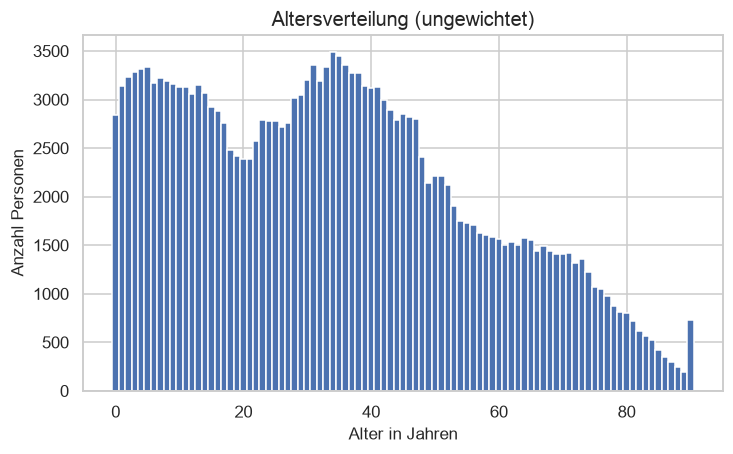

Anzahl Personen mit 88, 89 und 90 Jahren:
AAGE
88    241
89    195
90    725
Name: count, dtype: int64


In [21]:
# Alter in ganzen Jahren von 0 bis 90: ein Balken pro Lebensjahr.
# Die Bin-Grenzen liegen bei -0.5, 0.5, 1.5, ..., damit jedes Jahr genau in einem Balken landet.
# (Mit bins=20 wäre jeder Balken 4.5 Jahre breit: Manche fassen 4, andere 5 Jahre zusammen und erzeugen Scheinmuster.)
print(f"Histogramm über 'AAGE': alle {len(census)} Zeilen, keine fallen weg.")

fig, ax = plt.subplots()
ax.hist(census["AAGE"], bins=np.arange(0, 92) - 0.5)
ax.set_title("Altersverteilung (ungewichtet)")
ax.set_xlabel("Alter in Jahren")
ax.set_ylabel("Anzahl Personen")
plt.show()

print("Anzahl Personen mit 88, 89 und 90 Jahren:")
print(census["AAGE"].value_counts().reindex([88, 89, 90]))

- **Zwei Buckel:** Kinder (0 bis 15 Jahre) und eine breite Spitze bei etwa 30 bis 35 Jahren. Dazwischen liegt eine Delle bei 18 bis 22 Jahren. Mögliche Erklärungen, nicht geprüft: Die Spitze passt zu den Babyboom-Jahrgängen, die Delle zu den geburtenschwachen Jahrgängen der 1970er-Jahre. Ausserdem fehlen junge Erwachsene, die nicht in einem Privathaushalt leben, z.B. Soldaten in Kasernen (Abschnitt 2).
- **Die Spitze bei 90:** 725 Personen sind genau 90, aber nur 195 sind 89. Das ist das Top-Coding aus 4.2, hier direkt sichtbar: Alle Älteren wurden auf 90 gesetzt.
- **Nicht symmetrisch:** Mittelwert (34.49) und Median (33) liegen fast gleich, Signal 2 aus 4.2 hätte also "symmetrisch" gemeldet. Das Bild zeigt aber eine Verteilung mit zwei Gipfeln und einem langen Ausläufer nach rechts. Zwei Kennzahlen reichen nicht, um eine Form zu beschreiben.

#### Histogramm: Arbeitswochen

Links: alle 199523 Zeilen. Rechts: nur Personen mit mind. 1 Arbeitswoche, 103540 Zeilen.


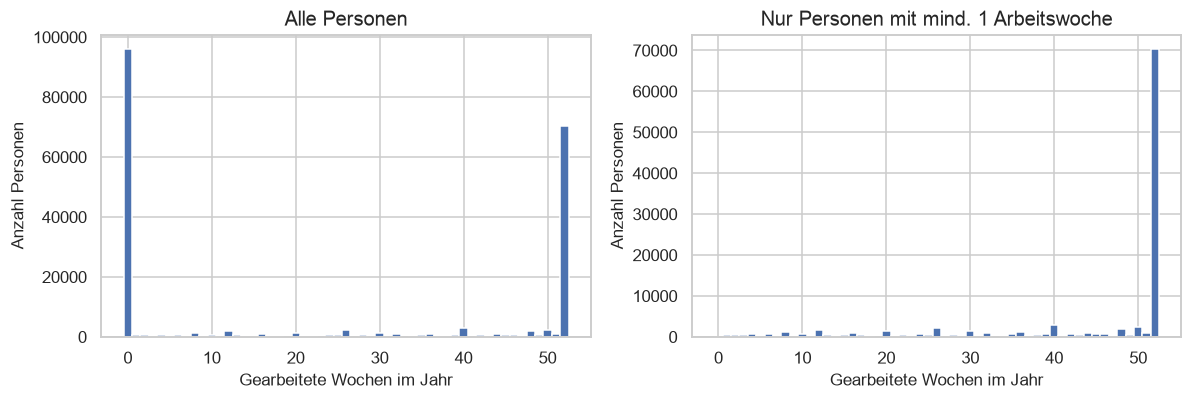

Anzahl Personen je Wochenzahl:
WKSWORK
25     457
26    2268
27      76
39     602
40    2790
41      88
Name: count, dtype: int64


In [22]:
arbeit = census["WKSWORK"]
print(f"Links: alle {len(arbeit)} Zeilen. Rechts: nur Personen mit mind. 1 Arbeitswoche, {(arbeit > 0).sum()} Zeilen.")

# Ein Balken pro Woche (0 bis 52), gleiche Logik wie beim Alter.
bins = np.arange(0, 54) - 0.5
fig, achsen = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
achsen[0].hist(arbeit, bins=bins)
achsen[0].set_title("Alle Personen")
achsen[1].hist(arbeit[arbeit > 0], bins=bins)
achsen[1].set_title("Nur Personen mit mind. 1 Arbeitswoche")
for ax in achsen:
    ax.set_xlabel("Gearbeitete Wochen im Jahr")
    ax.set_ylabel("Anzahl Personen")
plt.tight_layout()
plt.show()

# Häufen sich die Antworten bei runden Werten? Vergleich mit den direkten Nachbarn.
print("Anzahl Personen je Wochenzahl:")
print(arbeit.value_counts().reindex([25, 26, 27, 39, 40, 41]))

- **Links bestätigt sich Hypothese 2 aus 4.2:** zwei Häufungen, bei 0 (rund 96'000 Personen) und bei 52 (70'314), dazwischen fast nichts. Der Mittelwert (23.17) und der Median (8) liegen beide dort, wo kaum jemand ist. Für so eine Verteilung sind beide Kennzahlen wenig aussagekräftig.
- **Rechts:** Auch ohne die Nullen dominiert die 52. Wer arbeitet, arbeitet meistens das ganze Jahr.
- **Häufungen bei runden Werten:** 26 Wochen (ein halbes Jahr) geben 2'268 Personen an, die Nachbarn 25 und 27 nur 457 und 76. Bei 40 Wochen zeigt sich dasselbe. Das ist typisch für Selbstauskünfte: Menschen runden ihre Antwort ("etwa ein halbes Jahr"). Der Fachbegriff dafür ist **Heaping**, eine Form von Messfehler (Measurement Bias, VL01).

#### Histogramm: Dividenden und Kapitalgewinne

Für die Geldvariablen nehmen wir nur Werte > 0, sonst sieht man nur den Balken bei 0 (siehe 4.2). Links steht jeweils die normale (lineare) Skala, rechts die **logarithmische**. Dort ist jeder Schritt auf der x-Achse ein Faktor 10 (1, 10, 100, 1'000 ...). So werden kleine und grosse Beträge gleichzeitig sichtbar, was bei stark rechtsschiefen Verteilungen nötig ist.

DIVVAL > 0: 21141 von 199523 Zeilen (10.6%)
CAPGAIN > 0: 7379 von 199523 Zeilen (3.7%)


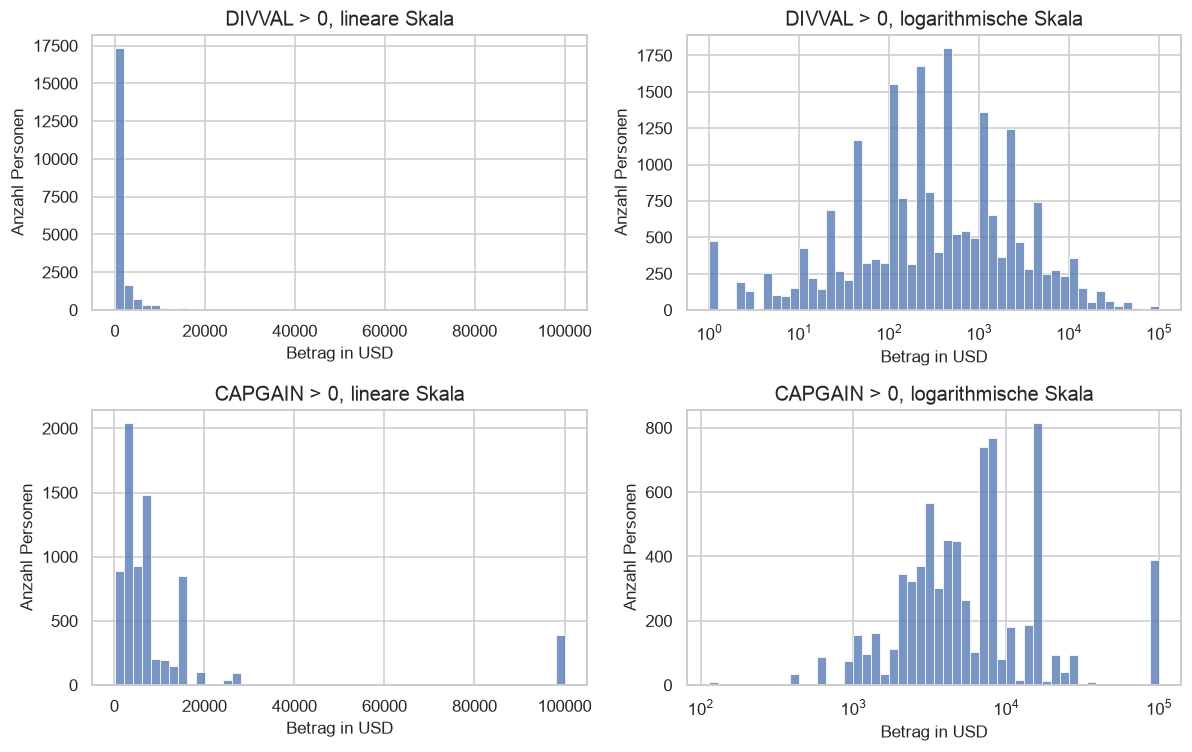


DIVVAL: 1477 verschiedene Beträge, davon 1 USD: 472 Mal. Die häufigsten:
DIVVAL
100     1148
500     1030
1000     894
200      866
50       832
Name: count, dtype: int64

CAPGAIN: 131 verschiedene Beträge, davon 1 USD: 0 Mal. Die häufigsten:
CAPGAIN
15024    788
7688     609
7298     582
99999    390
3103     237
Name: count, dtype: int64


In [23]:
fig, achsen = plt.subplots(2, 2, figsize=(11, 7))
for zeile, spalte in enumerate(["DIVVAL", "CAPGAIN"]):
    werte = census.loc[census[spalte] > 0, spalte]
    print(f"{spalte} > 0: {len(werte)} von {len(census)} Zeilen ({len(werte) / len(census):.1%})")

    sns.histplot(werte, bins=50, ax=achsen[zeile, 0])
    achsen[zeile, 0].set_title(f"{spalte} > 0, lineare Skala")
    sns.histplot(werte, bins=50, log_scale=True, ax=achsen[zeile, 1])   # log_scale: x-Achse logarithmisch
    achsen[zeile, 1].set_title(f"{spalte} > 0, logarithmische Skala")
    for ax in achsen[zeile]:
        ax.set_xlabel("Betrag in USD")
        ax.set_ylabel("Anzahl Personen")
plt.tight_layout()
plt.show()

# Welche Beträge kommen am häufigsten vor?
for spalte in ["DIVVAL", "CAPGAIN"]:
    werte = census.loc[census[spalte] > 0, spalte]
    print(f"\n{spalte}: {werte.nunique()} verschiedene Beträge, davon 1 USD: {(werte == 1).sum()} Mal. Die häufigsten:")
    print(werte.value_counts().head(5))

- **Auf der linearen Skala sieht man fast nichts:** Fast alle Werte kleben am linken Rand, weil wenige sehr hohe Beträge die Achse bis 100'000 strecken. Das ist die Rechtsschiefe aus 4.2 als Bild.
- **Auf der logarithmischen Skala wird die Form sichtbar:** Die Dividenden streuen über fünf Zehnerpotenzen, die meisten liegen etwa zwischen 100 und 1'000 USD.
- **Heaping auch bei `DIVVAL`:** Die häufigsten Beträge sind 100, 500, 1'000, 200 und 50 USD. Die Befragten schätzen ihre Dividenden offenbar und runden. Auffällig sind ausserdem 472 Personen mit genau 1 USD (der Balken ganz links). Ob das echte Beträge oder Platzhalter sind, wissen wir nicht.
- **`CAPGAIN` hat nur 131 verschiedene Beträge**, obwohl 7'379 Personen einen Wert > 0 haben. Die häufigsten sind keine runden Zahlen: 15'024, 7'688 und 7'298 USD kommen je knapp 600 bis 800 Mal vor. So würden Menschen nicht antworten. Vermutlich hat das Census Bureau die Beträge nachträglich zusammengefasst, belegt ist das durch unsere Dokumentation aber nicht. Für uns heisst das: `CAPGAIN` ist eher eine grobe Einteilung als ein exakter Betrag.
- **Top-Coding** ist bei `CAPGAIN` als einzelner Balken ganz rechts gut zu sehen (99'999 USD, 390 Personen).

#### Boxplot: Alter nach Einkommensklasse

Jetzt eine metrische Variable über Gruppen: Wie alt sind Personen unter und über 50k Einkommen? Wir nehmen nur Personen ab 15 Jahren, weil die Einkommensfragen erst ab 15 gestellt werden (Abschnitt 2) und unter 15 niemand über 50k liegt.

Personen unter 15 Jahren mit über 50k: 0
einkommen
unter 50k       139719
50k und mehr     12382
Name: count, dtype: int64
Boxplot: nur Personen ab 15 Jahren, 152101 von 199523 Zeilen.


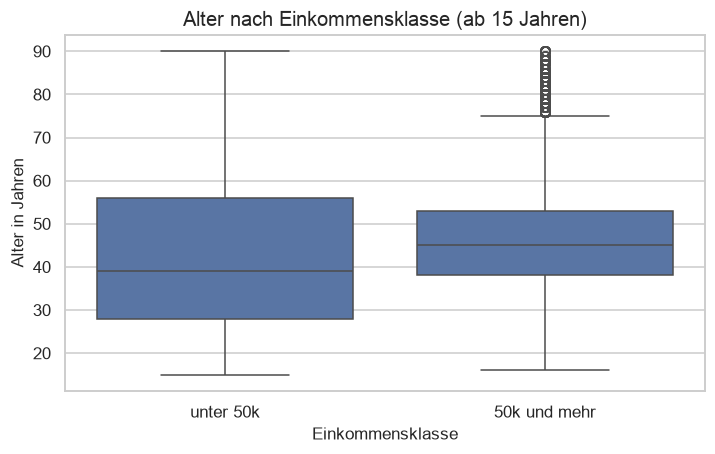

                 count   25%   50%   75%
einkommen                               
50k und mehr   12382.0  38.0  45.0  53.0
unter 50k     139719.0  28.0  39.0  56.0


In [24]:
ueber_50k = census["income"].str.strip() == "50000+."
print(f"Personen unter 15 Jahren mit über 50k: {(ueber_50k & (census['AAGE'] < 15)).sum()}")

ab15 = census[census["AAGE"] >= 15].copy()
# Klasse aus dem Wahrheitswert ueber_50k ableiten. So hängt das Label nur am bekannten Wert "50000+." (Abschnitt 2)
# und nicht an der genauen Schreibweise der unteren Klasse.
ab15["einkommen"] = ueber_50k.loc[ab15.index].map({True: "50k und mehr", False: "unter 50k"})
# Kontrolle: Keine Zeile darf ohne Klasse bleiben, sonst würde seaborn sie still weglassen.
print(ab15["einkommen"].value_counts(dropna=False))
print(f"Boxplot: nur Personen ab 15 Jahren, {len(ab15)} von {len(census)} Zeilen.")

sns.boxplot(x="einkommen", y="AAGE", data=ab15, order=["unter 50k", "50k und mehr"])
plt.title("Alter nach Einkommensklasse (ab 15 Jahren)")
plt.xlabel("Einkommensklasse")
plt.ylabel("Alter in Jahren")
plt.show()

# Die Zahlen hinter den Boxen: Die Box reicht vom 25-%- bis zum 75-%-Quantil, der Strich darin ist der Median.
print(ab15.groupby("einkommen")["AAGE"].describe()[["count", "25%", "50%", "75%"]])

- Personen mit 50k und mehr sind **älter**: Median 45 gegen 39 Jahre.
- Ihre Box ist aber **schmaler** (38 bis 53 gegen 28 bis 56 Jahre). Hohe Einkommen konzentrieren sich auf die mittleren Berufsjahre. Sehr junge und sehr alte Personen sind in dieser Gruppe selten, deshalb erscheinen die über 75-Jährigen dort als einzelne Punkte.
- Diese Punkte über dem oberen Strich (Whisker) gelten nach der Standardregel als Ausreisser. Was Box, Whisker und diese Regel genau bedeuten, kommt in VL02 und VL03.

#### Scatterplot: Stundenlohn gegen Alter

Zum Schluss zwei metrische Variablen gegeneinander. Wir nehmen nur Personen mit Stundenlohn > 0 und rechnen `AHRSPAY` wie in 4.2 festgestellt von Cents in USD um. Bei über 11'000 Punkten überdecken sich viele (**Overplotting**). Deshalb sind die Punkte klein und halbtransparent (`alpha=0.15`): Wo es dunkler wird, liegen viele Punkte übereinander.

Scatterplot: nur Personen mit Stundenlohn > 0, 11304 von 199523 Zeilen (5.7%).


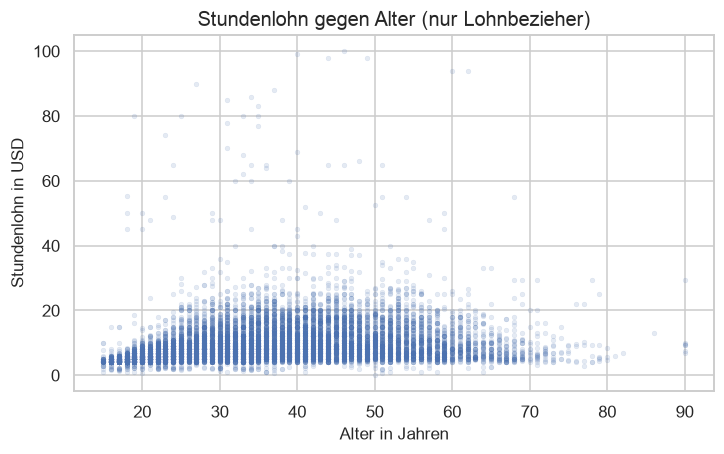

       count  median
AAGE                
15-24   2389    5.50
25-34   2975    8.50
35-44   2809    9.88
45-54   1925   10.00
55-64    918    8.62
65+      288    7.00


In [25]:
lohnbezieher = census[census["AHRSPAY"] > 0].copy()
lohnbezieher["stundenlohn_usd"] = lohnbezieher["AHRSPAY"] / 100   # Cents -> USD (siehe 4.2)
print(f"Scatterplot: nur Personen mit Stundenlohn > 0, {len(lohnbezieher)} von {len(census)} Zeilen ({len(lohnbezieher) / len(census):.1%}).")

sns.scatterplot(x="AAGE", y="stundenlohn_usd", data=lohnbezieher, alpha=0.15, s=10, edgecolor=None)
plt.title("Stundenlohn gegen Alter (nur Lohnbezieher)")
plt.xlabel("Alter in Jahren")
plt.ylabel("Stundenlohn in USD")
plt.show()

# Die Punktwolke ist schwer zu lesen, deshalb zusätzlich der Median je Altersgruppe.
altersgruppe = pd.cut(lohnbezieher["AAGE"], bins=[14, 24, 34, 44, 54, 64, 90],
                      labels=["15-24", "25-34", "35-44", "45-54", "55-64", "65+"])
print(lohnbezieher.groupby(altersgruppe, observed=True)["stundenlohn_usd"].agg(["count", "median"]).round(2))

- **Die senkrechten Streifen** entstehen, weil das Alter nur in ganzen Jahren erfasst ist. Das ist kein Muster in den Daten, sondern eine Folge der Messung.
- **Die meisten Löhne liegen zwischen etwa 4 und 20 USD pro Stunde** (5-%- und 95-%-Quantil aus 4.2: 4.25 und 20.00 USD), darüber gibt es nur vereinzelte Punkte bis knapp 100 USD.
- **Ein umgekehrtes U:** Der Median steigt von 5.50 USD (15 bis 24 Jahre) auf 10.00 USD (45 bis 54 Jahre) und fällt danach auf 7.00 USD (65+). Das passt zum Muster aus dem Boxplot.
- **Wer hier fehlt:** Nur 5.7 % aller Personen haben überhaupt einen Stundenlohn, und in 4.1 hatten 89 % der Ganzjahres-Erwerbstätigen bei `AHRSPAY` eine 0. Das Bild beschreibt also nur Personen, die im Stundenlohn bezahlt werden, nicht "die Erwerbstätigen".

**Erkenntnisse aus den Bildern** (ungewichtet, also Aussagen über die Stichprobe):

- **Bilder zeigen, was Kennzahlen verschweigen.** Beim Alter liegen Mittelwert und Median fast gleich, die Verteilung hat trotzdem zwei Gipfel. Bei den Arbeitswochen liegen Mittelwert und Median dort, wo kaum jemand ist.
- **Die Hypothesen aus 4.2 treffen zu:** zwei Häufungen bei `WKSWORK`, starke Rechtsschiefe bei `DIVVAL` und `CAPGAIN` (erst auf logarithmischer Skala lesbar), Top-Coding bei `AAGE` = 90 und `CAPGAIN` = 99'999.
- **Neu: Heaping.** Selbstauskünfte häufen sich bei runden Werten (26 und 40 Wochen, 100 und 1'000 USD Dividenden). Für grobe Kennzahlen ist das meist harmlos. Unterschiede zwischen benachbarten Werten (z.B. 25 gegen 26 Wochen) sollten wir aber nicht interpretieren.
- **Neu: `CAPGAIN` ist vermutlich nachträglich zusammengefasst.** Nur 131 verschiedene Beträge mit auffälligen, nicht runden Häufungen. Als exakten Betrag sollten wir die Variable nicht behandeln.
- **Neu: Alter hängt mit dem Einkommen zusammen, aber nicht linear.** Personen über 50k sind vor allem im mittleren Alter (Boxplot), und der Stundenlohn steigt bis etwa 45 bis 54 Jahre und fällt danach (Scatterplot).

**Hypothesen für die weiteren Notebooks** (EDA erzeugt Hypothesen, sie bestätigt sie nicht):
1. Alter und Stundenlohn hängen in Form eines umgekehrten U zusammen. Ein Korrelationskoeffizient, der nur lineare Zusammenhänge misst (VL04), würde diesen Zusammenhang unterschätzen.
2. Der Anteil der Personen über 50k ist im mittleren Alter am höchsten. Ob die Unterschiede zwischen den Altersgruppen belastbar sind, prüfen wir mit den Tests ab VL06.